---
title: Analyzing data
format:
    pdf: default
    ipynb: default
jupyter: python3
---

[Download notebook](notebooks/09_analyzing_data.ipynb).

In this chapter, we learn about statistical analysis with `scipy.stats`, including descriptive statistics, probability distributions, statistical tests, and maximum likelihood estimation.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## Descriptive statistics (`scipy.stats`) {#sec-descriptive}

The [`scipy.stats`](https://docs.scipy.org/doc/scipy/reference/stats.html) module provides functions for descriptive statistics and statistical tests. Here, `data` is a 1d array or list. Note that `stats.describe(data)` is different from the pandas method `df.describe()` (see @sec-pandas): `stats.describe` works on a single 1d array and additionally returns skewness and kurtosis, while `df.describe()` gives summary statistics (count, mean, std, min, quartiles, max) for all numeric columns of a DataFrame.

* `stats.describe(data)`: returns count, min, max, mean, variance, skewness, kurtosis.
* `stats.tmean(data, limits=(low, high))`: trimmed mean — the mean computed only over values in the interval `[low, high]`. Without `limits`, it returns the ordinary mean. This is useful to reduce the influence of outliers.
* `stats.tstd(data, limits=(low, high))`: trimmed standard deviation (same idea).
* `stats.tvar(data, limits=(low, high))`: trimmed variance (same idea).
* `stats.pearsonr(x, y)`: Pearson correlation coefficient and p-value.
* `stats.spearmanr(x, y)`: Spearman rank correlation and p-value.

In [ ]:
data = [1, 2, 3, 4, 5, 6, 7, 8]
result = stats.describe(data)
print("count =", result.nobs)
print("min, max =", result.minmax)
print("mean =", result.mean)
print("variance =", result.variance)
print("skewness =", result.skewness)
print("kurtosis =", result.kurtosis)

In [ ]:
data = np.array([2.3, 4.1, 3.7, 5.2, 4.8, 3.3])
print("trimmed mean =", stats.tmean(data))
print("std =", stats.tstd(data))
print("median =", np.median(data))

In [ ]:
# correlation
rng = np.random.default_rng(0)
x = rng.normal(size=50)
y = 2 * x + 0.5 * rng.normal(size=50)

r, p_value = stats.pearsonr(x, y)
print(f"Pearson r = {r:.4f}, p-value = {p_value:.6f}")

## Probability distributions (`scipy.stats`) {#sec-distributions}

`scipy.stats` provides a large number of probability distributions. Each distribution object has a common interface. Here, `dist` is a distribution object (e.g. `stats.norm`, `stats.expon`, `stats.poisson`).

* `dist.rvs(size=n, random_state=seed)`: draw `n` random samples. `size` can be an integer or a tuple for multi-dimensional output (e.g. `size=(3, 4)` for a 3×4 array). `random_state` accepts an integer seed or a `np.random.Generator` for reproducibility.
* `dist.pdf(x)` / `dist.pmf(x)`: density / probability mass function.
* `dist.cdf(x)`: cumulative distribution function.
* `dist.ppf(q)`: quantile function (inverse of `cdf`).
* `dist.mean()`, `dist.var()`, `dist.std()`: theoretical moments.
* `dist.fit(data)`: estimate parameters from data (maximum likelihood).

Each distribution takes its own parameters, e.g. `stats.norm(loc=mu, scale=sigma)`, `stats.poisson(mu=lam)`, `stats.binom(n=n, p=p)`. See the `scipy.stats` documentation for the full list.

For continuous distributions, the location-scale convention is used: `stats.norm(loc=mu, scale=sigma)` gives $\mathcal{N}(\mu, \sigma^2)$.

In [ ]:
# standard normal
print("mean =", stats.norm.mean())
print("pdf(0) =", stats.norm.pdf(0))
print("cdf(1.96) =", stats.norm.cdf(1.96))
print("ppf(0.975) =", stats.norm.ppf(0.975))

In [ ]:
# normal with given parameters
dist = stats.norm(loc=3, scale=2)
samples = dist.rvs(size=1000, random_state=42)
print("first 5 samples:", samples[:5])
print("theoretical mean =", dist.mean())
print("theoretical variance =", dist.var())
print("empirical mean =", np.mean(samples))
print("empirical variance =", np.var(samples))

In [ ]:
# exponential
print("Exp(1) mean =", stats.expon.mean())
print("Exp(1) samples:", stats.expon.rvs(size=5, random_state=0))

In [ ]:
# Poisson
print("Poisson(3) pmf(2) =", stats.poisson.pmf(2, mu=3))

In [ ]:
# binomial
print("Binom(10, 0.3) pmf(3) =", stats.binom.pmf(3, n=10, p=0.3))
print("Binom(10, 0.3) mean =", stats.binom.mean(n=10, p=0.3))

In [ ]:
# visualizing distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

x = np.linspace(-4, 4, 200)
axes[0].plot(x, stats.norm.pdf(x), label="N(0,1)")
axes[0].plot(x, stats.norm.pdf(x, loc=1, scale=0.5), label="N(1,0.25)")
axes[0].set_title("Normal distributions")
axes[0].legend()

x = np.linspace(0, 5, 200)
for lam in [0.5, 1.0, 2.0]:
    axes[1].plot(x, stats.expon.pdf(x, scale=1/lam), label=f"lambda={lam}")
axes[1].set_title("Exponential distributions")
axes[1].legend()

k = np.arange(0, 15)
for mu in [1, 3, 7]:
    axes[2].bar(k + 0.2*(mu-3)/4, stats.poisson.pmf(k, mu=mu), width=0.2, label=f"mu={mu}")
axes[2].set_title("Poisson distributions")
axes[2].legend()

plt.tight_layout()
plt.show()

## Statistical tests {#sec-tests}

`scipy.stats` provides many standard statistical tests. Each of the tests below returns a named tuple with two entries: a test statistic (`.statistic`) and a p-value (`.pvalue`). The p-value is the probability of observing a test statistic at least as extreme as the one computed, assuming the null hypothesis is true. A small p-value (typically below 0.05) suggests rejecting the null hypothesis.

* `stats.ttest_1samp(data, popmean)`: one-sample t-test (is the mean equal to `popmean`?).
* `stats.ttest_ind(sample1, sample2)`: two-sample t-test (do two independent samples have the same mean?).
* `stats.chisquare(observed)`: chi-squared test (do observed frequencies match expected frequencies?).
* `stats.kstest(data, 'norm')`: Kolmogorov-Smirnov test (does the data come from the given distribution?).

In [ ]:
rng = np.random.default_rng(0)
data = rng.normal(loc=5.2, scale=1.0, size=30)

# one-sample t-test
t_stat, p_value = stats.ttest_1samp(data, popmean=5.0)
print(f"t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")

In [ ]:
# two-sample t-test
sample1 = rng.normal(loc=5.0, scale=1.0, size=40)
sample2 = rng.normal(loc=5.5, scale=1.0, size=40)

t_stat, p_value = stats.ttest_ind(sample1, sample2)
print(f"t-statistic = {t_stat:.4f}, p-value = {p_value:.4f}")

In [ ]:
# chi-squared test
observed = np.array([18, 22, 20, 25, 15])
stat, p_value = stats.chisquare(observed)
print(f"chi2-statistic = {stat:.4f}, p-value = {p_value:.4f}")

In [ ]:
# Kolmogorov-Smirnov test
data = rng.normal(loc=0, scale=1, size=100)
stat, p_value = stats.kstest(data, 'norm')
print(f"KS statistic = {stat:.4f}, p-value = {p_value:.4f}")

## Maximum likelihood estimation {#sec-mle}

Maximum likelihood estimation (MLE) is one of the most important methods in statistics. Given i.i.d. observations $x_1, \dots, x_n$ from a distribution with density $f(x; \theta)$, the likelihood function is
$$L(\theta) = \prod_{i=1}^n f(x_i; \theta),$$
and the log-likelihood is
$$\ell(\theta) = \sum_{i=1}^n \log f(x_i; \theta).$$
The MLE is the parameter value that maximizes $\ell(\theta)$, or equivalently minimizes $-\ell(\theta)$.

In `scipy.stats`, the `fit` method computes the MLE for any distribution:

* `dist.fit(data)`: returns the MLE of the distribution parameters. Note that `dist.fit` returns only point estimates, not standard errors.
* `dist.logpdf(x, ...)`: log-density, useful for computing the log-likelihood.

For cases where no closed-form MLE exists, we use numerical optimization via `scipy.optimize.minimize` (see @sec-optimization). When using `method='BFGS'`, the result includes an approximate inverse Hessian (`result.hess_inv`), whose diagonal entries are the asymptotic variances of the parameter estimates. Taking square roots gives the standard errors.

In [ ]:
# MLE for the normal distribution
rng = np.random.default_rng(0)
true_mu = 3.0
true_sigma = 1.5
data = rng.normal(loc=true_mu, scale=true_sigma, size=200)

# analytical MLE
mu_hat = np.mean(data)
sigma_hat = np.std(data)  # np.std uses 1/n, which is the MLE
print(f"true mu = {true_mu}, MLE mu = {mu_hat:.4f}")
print(f"true sigma = {true_sigma}, MLE sigma = {sigma_hat:.4f}")

In [ ]:
# using scipy's fit method
mu_fit, sigma_fit = stats.norm.fit(data)
print(f"scipy fit: mu = {mu_fit:.4f}, sigma = {sigma_fit:.4f}")

In [ ]:
# MLE for the exponential distribution
# For Exp(lambda) with density lambda * exp(-lambda * x), the MLE is 
# lambda_hat = 1 / x_bar
true_lambda = 2.0
# rng.exponential(scale, size) draws from an exponential distribution
data_exp = rng.exponential(scale=1/true_lambda, size=150)  

lambda_hat = 1 / np.mean(data_exp)
print(f"true lambda = {true_lambda}, MLE lambda = {lambda_hat:.4f}")

In [ ]:
#| warning: false
# MLE via numerical optimization (when no closed form exists)
# Example: Gamma distribution
from scipy import optimize

true_shape = 2.5
true_scale = 1.3
# rng.gamma(shape, scale, size) draws from a gamma distribution
data_gamma = rng.gamma(shape=true_shape, scale=true_scale, size=300)  

def neg_log_likelihood_gamma(params):
    a, scale = params
    if a <= 0 or scale <= 0:
        return np.inf  # np.inf represents positive infinity
    return -np.sum(stats.gamma.logpdf(data_gamma, a=a, scale=scale))

# BFGS provides an approximate inverse Hessian, from which we get 
# standard errors
result = optimize.minimize(neg_log_likelihood_gamma, x0=[1.0, 1.0], 
    method='BFGS')
a_hat, scale_hat = result.x
print(f"true shape = {true_shape}, MLE shape = {a_hat:.4f}")
print(f"true scale = {true_scale}, MLE scale = {scale_hat:.4f}")

# standard errors from the inverse Hessian (asymptotic covariance matrix)
se = np.sqrt(np.diag(result.hess_inv))
print(f"std error of shape = {se[0]:.4f}")
print(f"std error of scale = {se[1]:.4f}")

In [ ]:
# compare with scipy's built-in fit
# floc=0 fixes the location parameter to 0
a_fit, loc_fit, scale_fit = stats.gamma.fit(data_gamma, floc=0)  
print(f"scipy fit: shape = {a_fit:.4f}, scale = {scale_fit:.4f}")

In [ ]:
# visualizing the MLE fit
x_grid = np.linspace(0, 12, 200)

plt.figure(figsize=(6, 4))
plt.hist(data_gamma, bins=30, density=True, alpha=0.7, label="data")
plt.plot(x_grid, stats.gamma.pdf(x_grid, a=true_shape, scale=true_scale),
         label=f"true: shape={true_shape}, scale={true_scale}")
plt.plot(x_grid, stats.gamma.pdf(x_grid, a=a_hat, scale=scale_hat),
         label=f"MLE: shape={a_hat:.2f}, scale={scale_hat:.2f}", 
         linestyle="--")
plt.xlabel("x")
plt.ylabel("density")
plt.title("Gamma distribution: data and MLE fit")
plt.legend()
plt.show()

The following plot shows the log-likelihood as a function of the two parameters shape and scale (for the gamma distribution fitted above). To evaluate a function on a 2d grid of parameter values, we use `np.meshgrid`: given two 1d arrays `shape_grid` and `scale_grid` of lengths $m$ and $n$, `np.meshgrid(shape_grid, scale_grid)` returns two $n \times m$ arrays `SHAPE` and `SCALE` such that `(SHAPE[i,j], SCALE[i,j])` is the point `(shape_grid[j], scale_grid[i])`. This allows evaluating the log-likelihood at every grid point with a simple loop (or vectorized). We store the results in an array created by `np.zeros_like(SHAPE)`, which returns an array of zeros with the same shape as `SHAPE`. The result is visualized with `plt.contourf`, which draws filled contour lines.

In [ ]:
# log-likelihood surface for the Gamma distribution
shape_grid = np.linspace(1.5, 4.0, 100)
scale_grid = np.linspace(0.7, 2.0, 100)
SHAPE, SCALE = np.meshgrid(shape_grid, scale_grid)

# option 1: explicit loop (clear, but slow for large grids)
log_lik = np.zeros_like(SHAPE)
for i in range(len(scale_grid)):
    for j in range(len(shape_grid)):
        log_lik[i, j] = np.sum(stats.gamma.logpdf(data_gamma, a=SHAPE[i, j], 
                scale=SCALE[i, j]))

# option 2: vectorized via broadcasting (much faster)
# data_gamma has shape (300,), SHAPE and SCALE have shape (100, 100)
# by reshaping data to (300, 1, 1), logpdf broadcasts to shape (300, 100, 100)
log_lik = np.sum(stats.gamma.logpdf(data_gamma[:, None, None], 
        a=SHAPE[None, :, :], scale=SCALE[None, :, :]), axis=0)

plt.figure(figsize=(6, 5))
plt.contourf(SHAPE, SCALE, log_lik, levels=30, cmap="viridis")
plt.colorbar(label="log-likelihood")
plt.xlabel("shape")
plt.ylabel("scale")
plt.title("Log-likelihood surface for Gamma(shape, scale)")
# "r*" is a format string: "r" = red color, "*" = star marker
plt.plot(a_hat, scale_hat, "r*", markersize=15, label="MLE")
plt.legend()
plt.show()

Plotting the log-likelihood surface helps build geometric intuition: the MLE is the peak of the surface. For well-behaved models, the surface is concave near the maximum, and the curvature encodes the precision of the estimate (related to the Fisher information).

## Linear regression {#sec-linear-regression}

Linear regression fits a linear model $y = \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p + \varepsilon$ to data, where $\varepsilon$ is the error term. The goal is to find the coefficients $\beta_0, \dots, \beta_p$ that minimize the sum of squared residuals $\sum_i (y_i - \hat{y}_i)^2$. This is called **ordinary least squares** (OLS).

* `stats.linregress(x, y)`: simple linear regression ($y = \beta_0 + \beta_1 x$). Returns a named tuple with `slope`, `intercept`, `rvalue` (correlation coefficient), `pvalue` (for the null hypothesis that the slope is zero), and `stderr` (standard error of the slope).
* `np.polyfit(x, y, deg)`: fit a polynomial of degree `deg` to the data. For `deg=1`, this gives the same result as linear regression.
* `np.polyval(coeffs, x)`: evaluate a polynomial with the given coefficients at `x`.

In [ ]:
# simple linear regression
rng = np.random.default_rng(42)
x = np.linspace(0, 10, 50)
y = 2.5 * x + 1.0 + rng.normal(scale=2.0, size=50)

result = stats.linregress(x, y)
print(f"slope = {result.slope:.4f}")
print(f"intercept = {result.intercept:.4f}")
print(f"R-squared = {result.rvalue**2:.4f}")
print(f"p-value = {result.pvalue:.6f}")
print(f"std error of slope = {result.stderr:.4f}")

In [ ]:
# visualizing the fit
plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=20, label="data")
plt.plot(x, result.slope * x + result.intercept, color="red",
    label="linear fit")
plt.xlabel("x")
plt.ylabel("y")
title = (f"y = {result.slope:.2f}x + {result.intercept:.2f}"
         f" (R² = {result.rvalue**2:.2f})")
plt.title(title)
plt.legend()
plt.show()

For multiple linear regression ($p > 1$ predictors), `scipy.stats.linregress` does not suffice. Instead, we can solve the normal equations directly using `np.linalg.lstsq`, which computes the least squares solution of an overdetermined system.

* `np.linalg.lstsq(A, b, rcond=None)`: solve $A \beta \approx b$ in the least squares sense. Returns a tuple of four values: the coefficient vector $\beta$, the sum of squared residuals (empty if `A` has fewer rows than columns), the rank of `A`, and its singular values.

In [ ]:
# multiple linear regression: y = beta0 + beta1 * x1 + beta2 * x2
rng = np.random.default_rng(7)
n = 100
x1 = rng.normal(size=n)
x2 = rng.normal(size=n)
y = 3.0 + 1.5 * x1 - 2.0 * x2 + rng.normal(scale=0.5, size=n)

# design matrix with intercept column
A = np.column_stack([np.ones(n), x1, x2])
beta, residuals, rank, sv = np.linalg.lstsq(A, y, rcond=None)
print(f"intercept = {beta[0]:.4f} (true: 3.0)")
print(f"beta1 = {beta[1]:.4f} (true: 1.5)")
print(f"beta2 = {beta[2]:.4f} (true: -2.0)")

In [ ]:
# R-squared for the multiple regression
y_pred = A @ beta
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r_squared = 1 - ss_res / ss_tot
print(f"R-squared = {r_squared:.4f}")

The R-squared value ($R^2 = 1 - \text{SS}_{\text{res}} / \text{SS}_{\text{tot}}$) measures the fraction of variance in $y$ explained by the model. A value close to 1 indicates a good fit.

## Principal component analysis (PCA) {#sec-pca}

**Principal component analysis** (PCA) is a technique for reducing the dimensionality of a dataset while retaining as much variance as possible. Given $n$ observations with $p$ features, PCA finds new orthogonal axes (called **principal components**) along which the data varies most. The first principal component captures the most variance, the second the most remaining variance (orthogonal to the first), and so on. This is useful for visualization (projecting high-dimensional data to 2d), noise reduction, and understanding the structure of a dataset.

Mathematically, let $X \in \mathbb{R}^{n \times p}$ be the data matrix with $n$ observations (rows) and $p$ features (columns). Write the rows as $x_1, \dots, x_n \in \mathbb{R}^p$. First, center the data by subtracting the column-wise mean $\bar{x} = \frac{1}{n} \sum_{i=1}^n x_i$:
$$\tilde{x}_i = x_i - \bar{x}, \qquad \tilde{X} = \begin{pmatrix} \tilde{x}_1^\top \\ \vdots \\ \tilde{x}_n^\top \end{pmatrix} \in \mathbb{R}^{n \times p}.$$
The **sample covariance matrix** $C \in \mathbb{R}^{p \times p}$ has entries
$$C_{jk} = \frac{1}{n-1} \sum_{i=1}^n \tilde{x}_{ij} \, \tilde{x}_{ik}, \qquad j,k = 1, \dots, p,$$
or in matrix form $C = \frac{1}{n-1} \tilde{X}^\top \tilde{X}$. The diagonal entry $C_{jj}$ is the sample variance of feature $j$, and $C_{jk}$ ($j \neq k$) measures how features $j$ and $k$ co-vary: positive if they tend to increase together, negative if one increases when the other decreases, and zero if they are uncorrelated.

Since $C$ is symmetric and positive semi-definite, it has an eigendecomposition $C = V \Lambda V^\top$, where $V = (v_1, \dots, v_p)$ is an orthogonal matrix of eigenvectors and $\Lambda = \text{diag}(\lambda_1, \dots, \lambda_p)$ contains the eigenvalues $\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_p \geq 0$. The eigenvector $v_j$ is the $j$-th **principal component direction**, and $\lambda_j$ is the variance of the data when projected onto $v_j$, i.e. $\lambda_j = \text{Var}(\tilde{X} v_j) = \frac{1}{n-1} \| \tilde{X} v_j \|^2$. The fraction of total variance explained by the first $k$ components is $\sum_{j=1}^k \lambda_j \,/\, \sum_{j=1}^p \lambda_j$.

To reduce the data from $p$ dimensions to $k$, we project: $X_k = \tilde{X} V_k$, where $V_k = (v_1, \dots, v_k) \in \mathbb{R}^{p \times k}$ contains the first $k$ eigenvectors. The resulting matrix $X_k \in \mathbb{R}^{n \times k}$ gives the coordinates of each observation in the new $k$-dimensional space.

* `np.cov(X, rowvar=False)`: compute $C = \frac{1}{n-1} \tilde{X}^\top \tilde{X}$, where rows of `X` are observations and columns are features. The option `rowvar=False` tells NumPy that rows are observations (the default assumes the opposite).
* `np.linalg.eigh(C)`: eigendecomposition of a symmetric matrix $C$. This is a variant of `np.linalg.eig` (see @sec-linalg) specialized for symmetric (Hermitian) matrices: it guarantees real eigenvalues and returns them sorted in ascending order. Returns eigenvalues and eigenvectors as columns.
* Projection: `X_centered @ V[:, :k]` computes $X_k = \tilde{X} V_k$, i.e. projects the data onto the first `k` principal components (after reversing the order so that the largest eigenvalue comes first).

In [ ]:
# generate correlated 3d data
rng = np.random.default_rng(42)
n = 200
z1 = rng.normal(size=n)
z2 = rng.normal(size=n)
z3 = rng.normal(size=n) * 0.1  # very little variance in this direction

# the three features are mixtures of z1, z2, z3
X = np.column_stack([
    2 * z1 + 0.5 * z2,
    z1 + z2,
    0.5 * z1 + 0.3 * z2 + z3
])

In [ ]:
# step 1: center the data
X_centered = X - X.mean(axis=0)

# step 2: compute the covariance matrix
C = np.cov(X_centered, rowvar=False)
print("Covariance matrix:")
print(np.round(C, 3))

In [ ]:
# step 3: eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(C)

# eigh returns eigenvalues in ascending order — reverse for descending
eigenvalues = eigenvalues[::-1]
eigenvectors = eigenvectors[:, ::-1]

print("Eigenvalues:", np.round(eigenvalues, 3))
print("Variance explained (%):", np.round(eigenvalues / eigenvalues.sum() * 100, 1))

In [ ]:
# step 4: project onto the first 2 principal components
X_pca = X_centered @ eigenvectors[:, :2]

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=15, alpha=0.6)
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("Data projected onto first two principal components")
plt.show()

In [ ]:
# scree plot: how much variance does each component explain?
plt.figure(figsize=(5, 3))
plt.bar(range(1, len(eigenvalues) + 1), eigenvalues / eigenvalues.sum() * 100)
plt.xlabel("Principal component")
plt.ylabel("Variance explained (%)")
plt.title("Scree plot")
plt.xticks(range(1, len(eigenvalues) + 1))
plt.show()

The **scree plot** shows the variance explained by each principal component. A sharp drop suggests that only the first few components carry meaningful information — the rest is mostly noise. In this example, the third component explains very little variance, so projecting from 3d to 2d loses almost no information.



## Exercises

**Exercise 1**
Load the [Auto MPG dataset](https://raw.githubusercontent.com/kirenz/datasets/master/Auto.csv) (originally from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/9/auto+mpg)) using `pd.read_csv`. Use `stats.describe` on the `mpg` column and compare the output with `df["mpg"].describe()`. Compute the Pearson and Spearman correlation between `weight` and `mpg`. Which is stronger? Why might they differ?

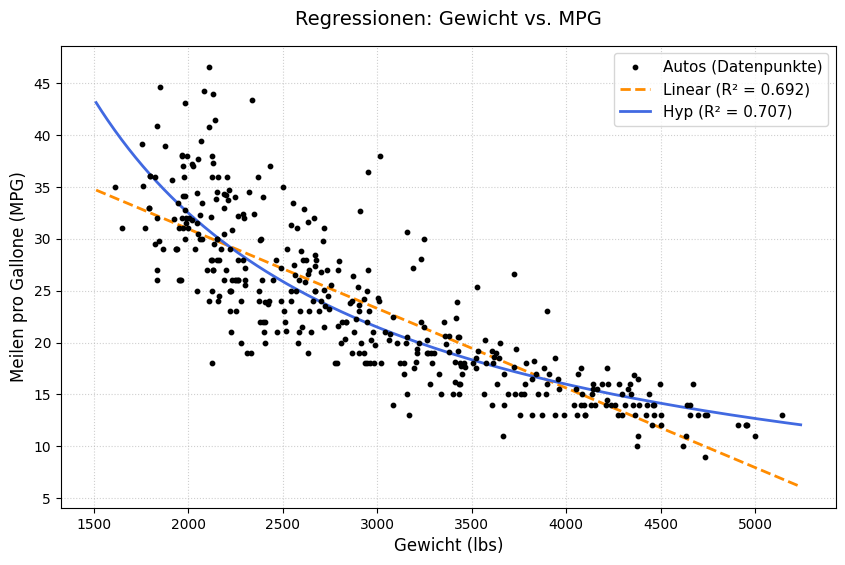

Gerade   : MPG = -0.00768 * Gewicht + 46.32
Hyperbel : MPG = 66102.7 / Gewicht + -0.55


In [1]:
# 09_data-ex_01-2.py 18-06-2026
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
# Verhalten im echten Datensatz: Wird die komplette Auto.csv geladen,
# verbrauchen schwerere Autos nicht unendlich linear mehr Sprit. Die
# Kurve flacht ab (typische 1/x-Beziehung). Da die Beziehung perfekt
# monoton, aber nicht perfekt linear ist, wird Spearman im gesamten
# Datensatz stärker als Pearson ...
df = pd.read_csv("Auto.csv") 
x = df["weight"].values
y = df["mpg"].values
# 2. Lineare Regression: y = m * x + c
slope, intercept, r_linear, _, _ = stats.linregress(x, y)
# 3. Hyperbolische Regression: y = a / x + b
# Transformation: fitten y gegen (1 / x)
slope_h, intercept_h, r_hyperbolic, _, _ = stats.linregress(1.0 / x, y)
# 4. Kontinuierliche X-Werte für glatte Kurven im Plot generieren
x_plot = np.linspace(x.min() - 100, x.max() + 100, 500)
y_linear_plot = slope * x_plot + intercept
y_hyperbolic_plot = (slope_h / x_plot) + intercept_h
# 5. Plot erstellen
plt.figure(figsize=(10, 6))
# Datenpunkte
plt.scatter(x, y, color="black", s=10, zorder=5, label="Autos (Datenpunkte)")
# Regressionslinien und Bestimmtheitsgrad R²(Anteil des Gew. an der abh. Varianz mpg)
# R² = 1-(Summe quadr.Abweichungen vom Modell(Residuen))/(Summe quadr.Abweichungen vom Mittelwert)
plt.plot(x_plot,y_linear_plot,color="darkorange",linestyle="--",linewidth=2,
         label=f"Linear (R² = {r_linear**2:.3f})",
)
plt.plot(x_plot,y_hyperbolic_plot,color="royalblue",linewidth=2,
         label=f"Hyp (R² = {r_hyperbolic**2:.3f})",)
# Beschriftungen und Styling
plt.title("Regressionen: Gewicht vs. MPG", fontsize=14, pad=15)
plt.xlabel("Gewicht (lbs)", fontsize=12)
plt.ylabel("Meilen pro Gallone (MPG)", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=11)
# Diagramm anzeigen
plt.show()
# Formeln ausgeben
print(f"Gerade   : MPG = {slope:.5f} * Gewicht + {intercept:.2f}")
print(f"Hyperbel : MPG = {slope_h:.1f} / Gewicht + {intercept_h:.2f}")


**Exercise 2**
Generate 1000 samples from a $\mathcal{N}(2, 3^2)$ distribution. Plot a histogram together with the true density, the density of the MLE fit (`stats.norm.fit`), and the density of a fit where you deliberately set $\mu = 0$ (wrong mean). Add a legend.

In [ ]:
# Exercise 2

**Exercise 3**
Load the [Advertising dataset](https://raw.githubusercontent.com/kirenz/datasets/master/advertising.csv) (from the textbook *An Introduction to Statistical Learning* by James, Witten, Hastie, and Tibshirani) using `pd.read_csv`. Use `stats.linregress` to fit a simple linear regression of `sales` on `TV`. Report the slope, intercept, R-squared, and p-value. Plot the data as a scatter plot with the regression line. Then fit a multiple regression of `sales` on `TV`, `radio`, and `newspaper` using `np.linalg.lstsq`. Compare the R-squared values. Which predictor contributes least?

--- Lineare Regression (sales ~ TV) ---
Steigung (Slope):      0.0475
Achsenabschnitt (Int): 7.0326
Bestimmtheitsmaß (R²): 0.6119
p-Wert:                0.0000

--- Multiple Lineare Regression (sales ~ TV + radio + newspaper) ---
Koeffizienten: Intercept=2.9389, TV=0.0458, radio=0.1885, newspaper=-0.0010
Multiples R²:  0.8972



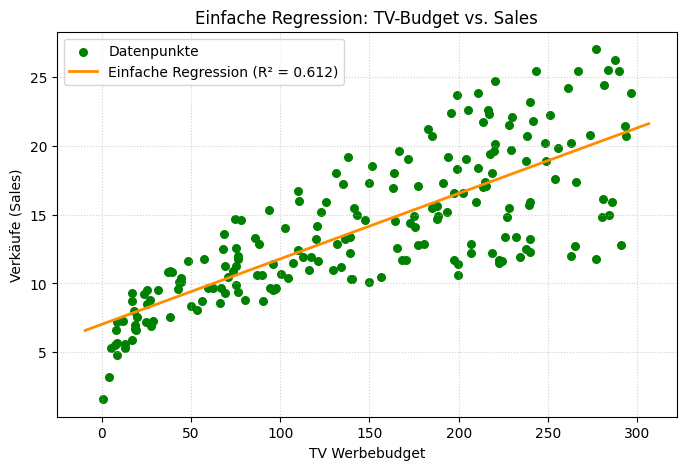

In [2]:
# 09_data-ex_03-1.py 18-06-2026
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats

# 1. Daten Ansatz logistisches Modell
# Sales= beta0 + beta1*TV + beta2*Radio + beta3*TV*Radio
df = pd.read_csv("advertising.csv") 
# --- TEIL 1: Einfache lineare Regression (sales basierend auf TV) ---
slope, intercept, r_val, p_val, _ = stats.linregress(df["TV"], df["sales"])
r_squared_simple = r_val**2

print("--- Lineare Regression (sales ~ TV) ---")
print(f"Steigung (Slope):      {slope:.4f}")
print(f"Achsenabschnitt (Int): {intercept:.4f}")
print(f"Bestimmtheitsmaß (R²): {r_squared_simple:.4f}")
print(f"p-Wert:                {p_val:.4f}\n")

# --- TEIL 2: Multiple lineare Regression mittels np.linalg.lstsq ---
# Erstellen der Design-Matrix X (inklusive einer Spalte aus Einsen für den Intercept)
X = df[["TV", "radio", "newspaper"]].values
X_with_intercept = np.hstack([np.ones((X.shape[0], 1)), X])
y = df["sales"].values

# Kleinst-Quadrate-Schätzung (lstsq)
beta, residuals, rank, _ = np.linalg.lstsq(
    X_with_intercept, y, rcond=None
)

# R² für die multiple Regression berechnen
ss_tot = np.sum((y - np.mean(y)) ** 2)
ss_res = (
    residuals[0]
    if len(residuals) > 0
    else np.sum((y - np.dot(X_with_intercept, beta)) ** 2)
)
r_squared_multiple = 1 - (ss_res / ss_tot)

print("--- Multiple Lineare Regression (sales ~ TV + radio + newspaper) ---")
print(
    f"Koeffizienten: Intercept={beta[0]:.4f}, TV={beta[1]:.4f}, radio={beta[2]:.4f}, newspaper={beta[3]:.4f}"
)
print(f"Multiples R²:  {r_squared_multiple:.4f}\n")

# --- TEIL 3: Plot erstellen ---
plt.figure(figsize=(8, 5))
plt.scatter(df["TV"], df["sales"], color="green", s=30, label="Datenpunkte")

# Regressionsgerade für TV plotten
x_line = np.linspace(df["TV"].min() - 10, df["TV"].max() + 10, 100)
y_line = slope * x_line + intercept
plt.plot(
    x_line,
    y_line,
    color="darkorange",
    linewidth=2,
    label=f"Einfache Regression (R² = {r_squared_simple:.3f})",
)

plt.title("Einfache Regression: TV-Budget vs. Sales")
plt.xlabel("TV Werbebudget")
plt.ylabel("Verkäufe (Sales)")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()
plt.show()


--- Das Duell der Invarianten ---
Linear Bestimmtheitsmaß (R²): 0.6119
Logistic. Bestimmth.maß (R²): 0.6198

--- Formparameter der S-Kurve ---
Sättigungsgrenze (L + b):             28.83 Sales
Inflexionspunkt / Wendepunkt (x0):   -1953.04 TV-Budget
Wachstumsrate (k):                   0.0032


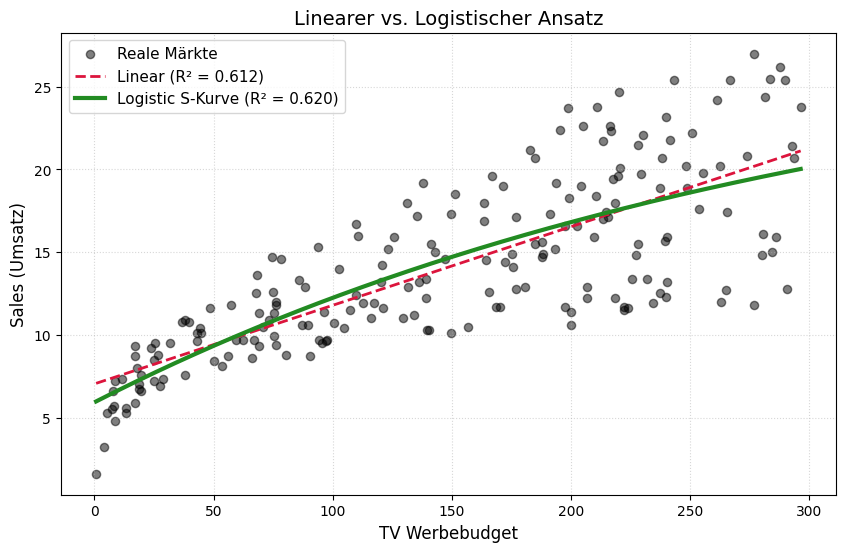

In [3]:
# 09_data-ex_03-2.py 18-06-2026
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import scipy.stats as stats

# 1. Kompletter Datensatz einlesen
df = pd.read_csv("advertising.csv")
X_tv = df["TV"].values
y_sales = df["sales"].values

# 2. lineare Regression (als Benchmark)
slope, intercept, r_val, _, _ = stats.linregress(X_tv, y_sales)
r2_linear = r_val**2


# 3. Logistischer Regressor (Wachstumsfunktion / S-Kurve)
# Formel: f(x) = L / (1 + exp(-k * (x - x0))) + b
def logistic_growth(x, L, k, x0, b):
    return L / (1 + np.exp(-k * (x - x0))) + b

# curve_fit sucht die optimalen Parameter über kleinste Quadrate
# Startwerte (p0): Kapazität=20, Steigung=0.01, Wendepunkt=100, Baseline=5
popt, _ = curve_fit(
    logistic_growth, X_tv, y_sales, p0=[20, 0.01, 100, 5], maxfev=10000
)
L, k, x0, b = popt

# R² für das logistische Modell berechnen
y_pred_logistic = logistic_growth(X_tv, *popt)
ss_res = np.sum((y_sales - y_pred_logistic) ** 2)
ss_tot = np.sum((y_sales - np.mean(y_sales)) ** 2)
r2_logistic = 1 - (ss_res / ss_tot)

# 4. Ergebnisse im Terminal 
print("--- Das Duell der Invarianten ---")
print(f"Linear Bestimmtheitsmaß (R²): {r2_linear:.4f}")
print(f"Logistic. Bestimmth.maß (R²): {r2_logistic:.4f}")

print("\n--- Formparameter der S-Kurve ---")
print(f"Sättigungsgrenze (L + b):             {L + b:.2f} Sales")
print(f"Inflexionspunkt / Wendepunkt (x0):   {x0:.2f} TV-Budget")
print(f"Wachstumsrate (k):                   {k:.4f}")

# 5. Neuer Plot
plt.figure(figsize=(10, 6))
plt.scatter(
    X_tv, y_sales, color="black", alpha=0.5, s=35, label="Reale Märkte"
)

# Kontinuierliche x-Achse für Kurven
x_curve = np.linspace(X_tv.min(), X_tv.max(), 500)

# Plots der beiden Ansätze
plt.plot(
    x_curve,
    slope * x_curve + intercept,
    color="crimson",
    linestyle="--",
    linewidth=2,
    label=f"Linear (R² = {r2_linear:.3f})",
)
plt.plot(
    x_curve,
    logistic_growth(x_curve, *popt),
    color="forestgreen",
    linewidth=3,
    label=f"Logistic S-Kurve (R² = {r2_logistic:.3f})",
)

plt.title("Linearer vs. Logistischer Ansatz", fontsize=14)
plt.xlabel("TV Werbebudget", fontsize=12)
plt.ylabel("Sales (Umsatz)", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(fontsize=11)
plt.show()


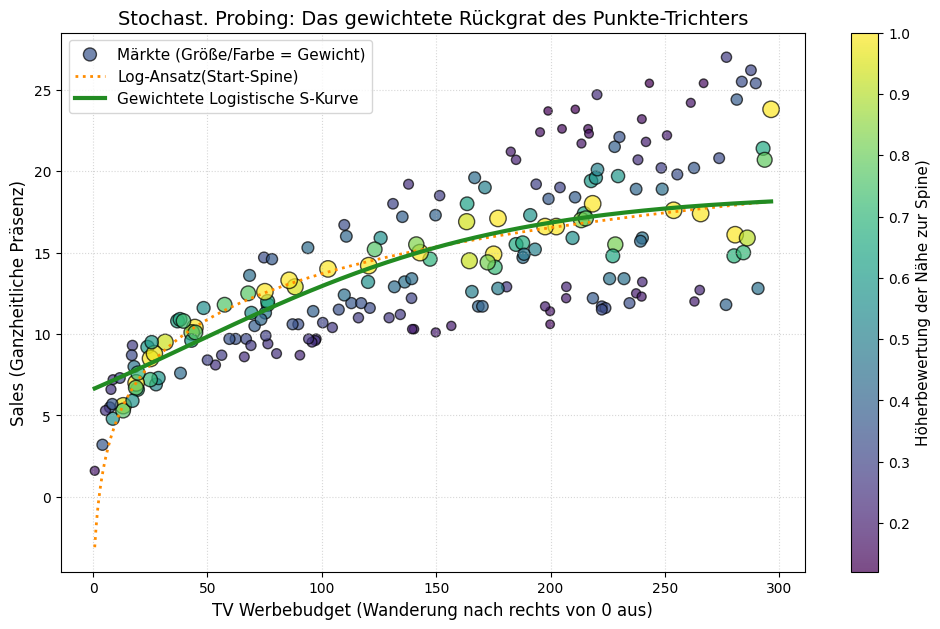

In [4]:
# 09_data-ex_03-4.py 18-06-2026
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# 1. Daten laden (200 Märkte)

df = pd.read_csv("advertising.csv")
x = df["TV"].values
y = df["sales"].values

# 2. Spine-Ansatz: Um 1 Einheit verschobene Log-Kurve als Startwert-Geometrie
def log_spine_base(x, a, b):
    return a * np.log(x + 1) + b

# Vorab-Fit des Rückgrat-Ansatzes für erste Orientierung 
popt_base, _ = curve_fit(log_spine_base, x, y, p0=[5, 1])
y_spine_initial = log_spine_base(x, *popt_base)

# 3. Das "Sicht-Spalten-Scanning" & Dynamische Gewichtung
# Wir teilen die x-Achse in vertikale Meßstreifen (Bins) auf
num_bins = 15
bins = np.linspace(x.min(), x.max(), num_bins + 1)
weights = np.ones_like(x)

for i in range(num_bins):
    # Maske für Punkte, die im aktuellen "Spalt" liegen
    in_bin = (x >= bins[i]) & (x < bins[i+1])
    count = np.sum(in_bin)
    
    if count > 0:
        # Innere Abstände zur vorläufigen Spine berechnen
        dist_to_spine = np.abs(y[in_bin] - y_spine_initial[in_bin])
        
        # Doppel-Paradigma der Streifen-Gewichtung:
        # 1. Je weniger Punkte im Spalt (1 / count), desto stärker zählt die Nähe.
        # 2. Je näher am Rückgrat (1 / (dist + 1)), desto höher das Gewicht.
        # Ein kleiner Dämpfer (+1), um Division durch Null zu verhindern.
        bin_weights = (1.0 / count) * (1.0 / (dist_to_spine + 1.0))
        
        # Gewichte normalisieren, damit die Streifen vergleichbar bleiben
        weights[in_bin] = bin_weights / np.max(bin_weights)

# 4. Die endgültige logistische S-Kurve unter Honorierung der Gewichte fitten
def logistic_spine(x, L, k, x0, b):
    exponent = -k * (x - x0)
    exponent = np.clip(exponent, -500, 500)
    return L / (1 + np.exp(exponent)) + b

# curve_fit akzeptiert 'sigma', was dem Kehrwert der Gewichtung entspricht
# Kleine sigma-Werte => hohe Gewichtung (hohe Priorität für Optimierer)
sigma = 1.0 / weights

popt_logistic, _ = curve_fit(
    logistic_spine, x, y, 
    p0=[20, 0.02, 100, 5], 
    sigma=sigma, 
    bounds=([5, 0.001, 10, 0], [40, 0.1, 250, 15])
)

# 5. Visualisierung des fließenden Gleichgewichts
plt.figure(figsize=(12, 7))

# Die Datenpunkte – farblich codiert nach Gewichtung
scatter = plt.scatter(
    x, y, c=weights, cmap="viridis", s=weights*120 + 20, 
    edgecolors="black", alpha=0.7, label="Märkte (Größe/Farbe = Gewicht)"
)
cbar = plt.colorbar(scatter)
cbar.set_label("Höherbewertung der Nähe zur Spine)", fontsize=11)

# Kurven zeichnen
x_plot = np.linspace(x.min(), x.max(), 500)
plt.plot(
    x_plot, log_spine_base(x_plot, *popt_base), 
    color="darkorange", linestyle=":", linewidth=2, label="Log-Ansatz(Start-Spine)"
)
plt.plot(
    x_plot, logistic_spine(x_plot, *popt_logistic), 
    color="forestgreen", linewidth=3, label="Gewichtete Logistische S-Kurve"
)

plt.title("Stochast. Probing: Das gewichtete Rückgrat des Punkte-Trichters", fontsize=14)
plt.xlabel("TV Werbebudget (Wanderung nach rechts von 0 aus)", fontsize=12)
plt.ylabel("Sales (Ganzheitliche Präsenz)", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend(fontsize=11)
plt.show()


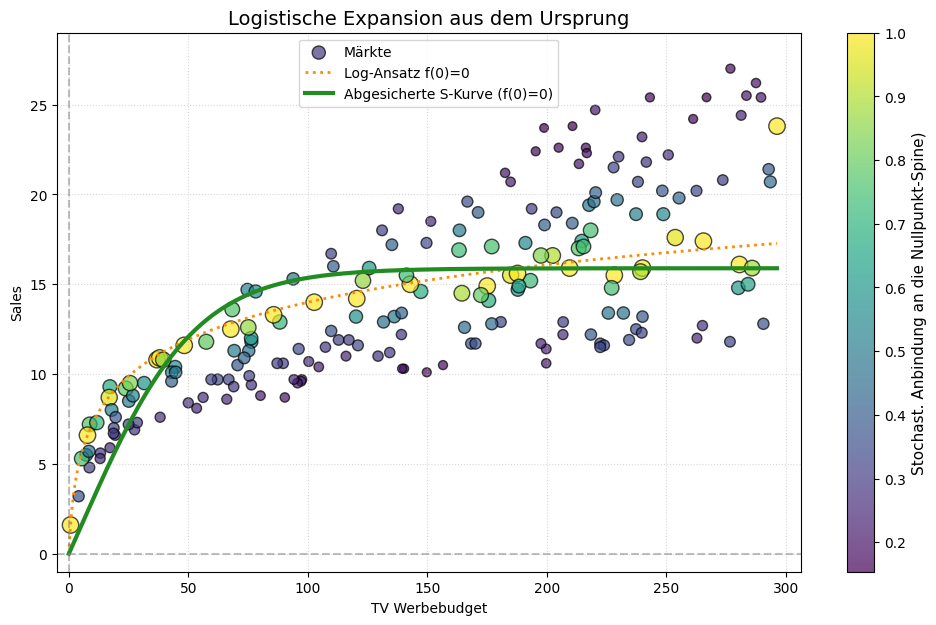

In [5]:
# 09_data-ex_03-7.py 18-06-2026
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# 1. Daten laden (Ihre 200 Märkte)
df = pd.read_csv("advertising.csv")
x = df["TV"].values
y = df["sales"].values


# 2. Log-Ansatz mit erzwungenem Nulldurchgang 
def log_spine_zero(x, a):
    return a * np.log(x + 1)

popt_base, _ = curve_fit(log_spine_zero, x, y, p0=[1.0])
y_spine_initial = log_spine_zero(x, *popt_base)

# 3. Spalt-Scanning
num_bins = 15
bins = np.linspace(x.min(), x.max(), num_bins + 1)
weights = np.ones_like(x)

for i in range(num_bins):
    in_bin = (x >= bins[i]) & (x < bins[i + 1])
    count = np.sum(in_bin)
    if count > 0:
        dist_to_spine = np.abs(y[in_bin] - y_spine_initial[in_bin])
        bin_weights = (1.0 / count) * (1.0 / (dist_to_spine + 1.0))
        max_bw = np.max(bin_weights)
        weights[in_bin] = bin_weights / max_bw if max_bw > 0 else 0.001

# sicherndes Sigma-Clipping
sigma = 1.0 / weights
sigma = np.clip(sigma, 0.01, 100.0)


# --- ABSICHERUNG (Sicherer Logistischer Kern) ---
def safe_sigmoid(t):
    # Verhindert Überlauf (inf) und Unterlauf (0 -> NaN bei Subtraktion)
    t_clipped = np.clip(t, -100, 100)
    return 1.0 / (1.0 + np.exp(-t_clipped))


def logistic_spine_zero(x, L, k, x0):
    # Jede einzelne mathematische Operation wird vor infs gesichert
    k_safe = np.clip(k, 0.0001, 1.0)
    x0_safe = np.clip(x0, 1.0, 500.0)

    # Der eigentliche Funktionswert und sein Offset im Ursprung
    val = safe_sigmoid(k_safe * (x - x0_safe))
    zero_offset = safe_sigmoid(k_safe * (-x0_safe))

    # Die Differenz wird berechnet – garantiert frei von NaNs
    res = L * (val - zero_offset)
    return np.nan_to_num(res, nan=0.0, posinf=40.0, neginf=0.0)


# Physikalisch naheliegende Leitplanken für den Lauf
lower_bounds = [1.0, 0.001, 5.0]
upper_bounds = [50.0, 0.2, 300.0]

popt_logistic, _ = curve_fit(
    logistic_spine_zero,
    x,
    y,
    p0=[25.0, 0.01, 50.0],
    sigma=sigma,
    bounds=(lower_bounds, upper_bounds),
    maxfev=30000,
)

# 5. Erzwungener Plot aus dem Ursprung
plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    x,
    y,
    c=weights,
    cmap="viridis",
    s=weights * 120 + 20,
    edgecolors="black",
    alpha=0.7,
    label="Märkte",
)
cbar = plt.colorbar(scatter)
cbar.set_label("Stochast. Anbindung an die Nullpunkt-Spine)", fontsize=11
)

x_plot = np.linspace(0, x.max(), 500)
plt.plot(
    x_plot,
    log_spine_zero(x_plot, *popt_base),
    color="darkorange",
    linestyle=":",
    linewidth=2,
    label="Log-Ansatz f(0)=0",
)
plt.plot(
    x_plot,
    logistic_spine_zero(x_plot, *popt_logistic),
    color="forestgreen",
    linewidth=3,
    label="Abgesicherte S-Kurve (f(0)=0)",
)

plt.axvline(0, color="gray", linestyle="--", alpha=0.5)
plt.axhline(0, color="gray", linestyle="--", alpha=0.5)

plt.title("Logistische Expansion aus dem Ursprung",
    fontsize=14,
)
plt.xlabel("TV Werbebudget")
plt.ylabel("Sales")
plt.xlim(-5, x.max() + 10)
plt.ylim(-1, y.max() + 2)
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend()
plt.show()


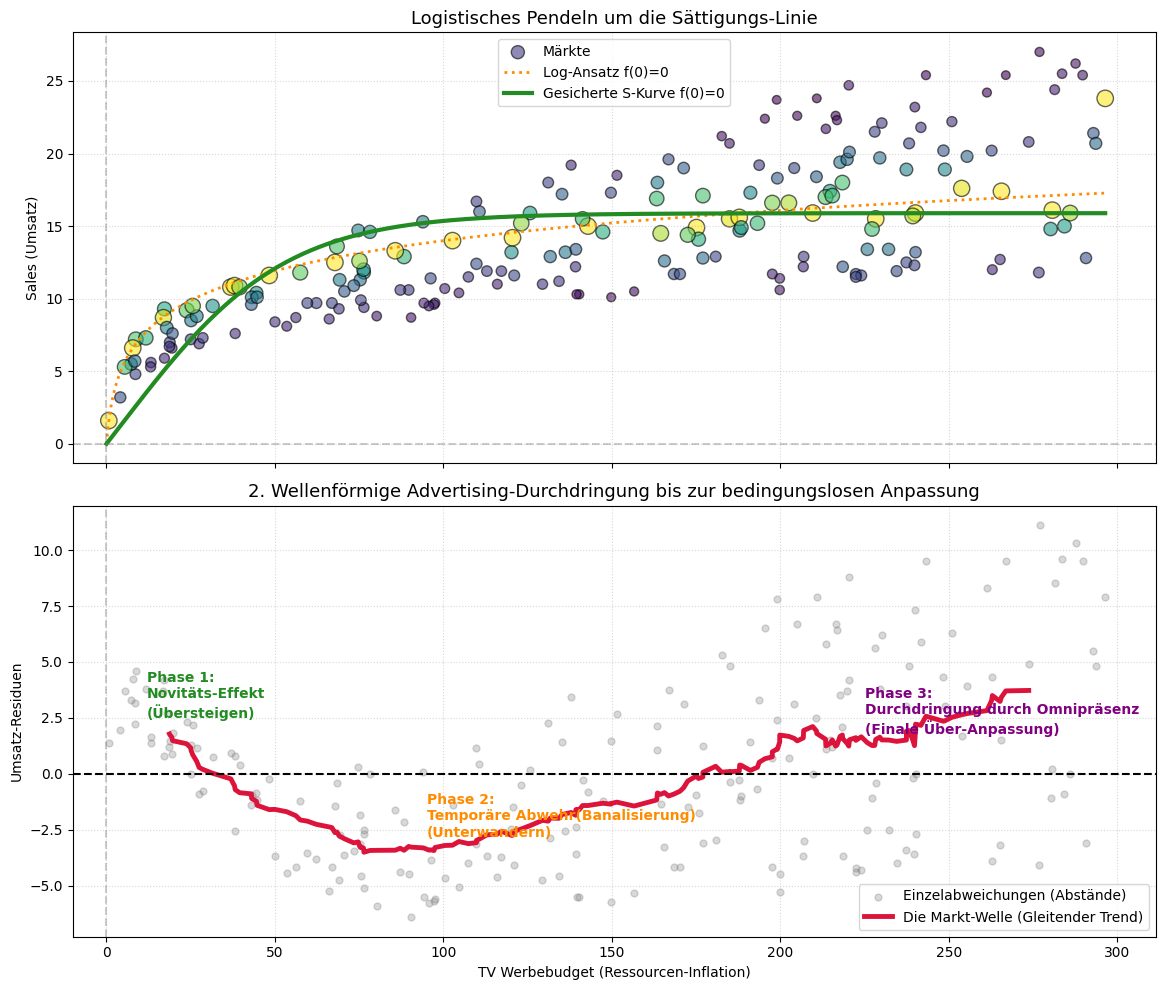

In [7]:
# 09_data-ex_03-8.py 18-06-2026
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit

# =====================================================================
# 1. EINLESEN 
# =====================================================================
# OPTION A: Direktes Streamen vom offiziellen ISLR-Server der Autoren
# url = "https://statlearning.com"
# df = pd.read_csv(url, index_col=0)
# OPTION B: Falls Sie die Datei lokal im selben Ordner
df = pd.read_csv("advertising.csv")

# Extrahieren der physikalischen Trägerachsen
x = df["TV"].values
y = df["sales"].values

# =====================================================================
# 2. SPINE-ANSATZ mit Nulldurchgang f(0)=0
# =====================================================================
# Logarithmischer Ansatz für stochastisches Probing
def log_spine_zero(x, a):
    return a * np.log(x + 1)


popt_base, _ = curve_fit(log_spine_zero, x, y, p0=[1.0])
y_spine_initial = log_spine_zero(x, *popt_base)

# Spalt-Scanning zur dynamischen Gewichtung der "Trichterwolke"
num_bins = 15
bins = np.linspace(x.min(), x.max(), num_bins + 1)
weights = np.ones_like(x)

for i in range(num_bins):
    in_bin = (x >= bins[i]) & (x < bins[i + 1])
    count = np.sum(in_bin)
    if count > 0:
        dist_to_spine = np.abs(y[in_bin] - y_spine_initial[in_bin])
        bin_weights = (1.0 / count) * (1.0 / (dist_to_spine + 1.0))
        max_bw = np.max(bin_weights)
        weights[in_bin] = bin_weights / max_bw if max_bw > 0 else 0.001

# Varianz-Clipping (Verhindert Infs und NaNs im curve_fit)
sigma = np.clip(1.0 / weights, 0.01, 100.0)


# Abgesicherter logistischer Kern mit erzwungenem Nulldurchgang
def safe_sigmoid(t):
    return 1.0 / (1.0 + np.exp(-np.clip(t, -100, 100)))


def logistic_spine_zero(x, L, k, x0):
    k_safe = np.clip(k, 0.0001, 1.0)
    x0_safe = np.clip(x0, 1.0, 500.0)

    val = safe_sigmoid(k_safe * (x - x0_safe))
    zero_offset = safe_sigmoid(k_safe * (-x0_safe))

    res = L * (val - zero_offset)
    return np.nan_to_num(res, nan=0.0, posinf=40.0, neginf=0.0)


# Fit über alle 200 Datenpunkte
popt_logistic, _ = curve_fit(
    logistic_spine_zero,
    x,
    y,
    p0=[25.0, 0.01, 50.0],
    sigma=sigma,
    bounds=([1.0, 0.001, 5.0], [50.0, 0.2, 300.0]),
    maxfev=30000,
)

# =====================================================================
# 3. Residuen-Analyse des Pendelns um die Spine-Linie
# =====================================================================
y_pred_final = logistic_spine_zero(x, *popt_logistic)
residuen = y - y_pred_final

# Sortieren nach Budget für den chronologischen Lauf nach rechts
sort_idx = np.argsort(x)
x_sorted = x[sort_idx]
res_sorted = residuen[sort_idx]

# Gleitender Mittelwert, um Welle aus stochastischem Rauschen zu holen
window_size = 30
res_smoothed = (
    pd.Series(res_sorted).rolling(window=window_size, center=True).mean().values
)

# =====================================================================
# 4. DOPPEL-GRAFIK Trichter-Wolke und Pendelbewegung um die Spine-Linie
# =====================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# --- OBERER PLOT: Spine-Linie aus dem Ursprung ---
scatter = ax1.scatter(
    x,
    y,
    c=weights,
    cmap="viridis",
    s=weights * 120 + 20,
    edgecolors="black",
    alpha=0.6,
    label="Märkte",
)
x_plot = np.linspace(0, x.max(), 500)
ax1.plot(
    x_plot,
    log_spine_zero(x_plot, *popt_base),
    color="darkorange",
    linestyle=":",
    linewidth=2,
    label="Log-Ansatz f(0)=0",
)
ax1.plot(
    x_plot,
    logistic_spine_zero(x_plot, *popt_logistic),
    color="forestgreen",
    linewidth=3,
    label="Gesicherte S-Kurve f(0)=0",
)
ax1.axvline(0, color="gray", linestyle="--", alpha=0.4)
ax1.axhline(0, color="gray", linestyle="--", alpha=0.4)
ax1.set_title("Logistisches Pendeln um die Sättigungs-Linie",
    fontsize=13,
)
ax1.set_ylabel("Sales (Umsatz)")
ax1.grid(True, linestyle=":", alpha=0.5)
ax1.legend()

# --- UNTERER PLOT: Das Drei-Phasen-Pendeln ---
ax2.scatter(
    x_sorted,
    res_sorted,
    color="gray",
    alpha=0.3,
    s=25,
    label="Einzelabweichungen (Abstände)",
)
ax2.plot(
    x_sorted,
    res_smoothed,
    color="crimson",
    linewidth=3.5,
    label="Die Markt-Welle (Gleitender Trend)",
)
ax2.axhline(0, color="black", linestyle="--", linewidth=1.5)
ax2.axvline(0, color="gray", linestyle="--", alpha=0.4)

# Interpretation der Pendelphasen
ax2.text(
    12,
    2.5,
    "Phase 1:\nNovitäts-Effekt\n(Übersteigen)",
    color="forestgreen",
    fontsize=10,
    fontweight="bold",
)
ax2.text(
    95,
    -2.8,
    "Phase 2:\nTemporäre Abwehr(Banalisierung)\n(Unterwandern)",
    color="darkorange",
    fontsize=10,
    fontweight="bold",
)
ax2.text(
    225,
    1.8,
    "Phase 3:\nDurchdringung durch Omnipräsenz\n(Finale Über-Anpassung)",
    color="purple",
    fontsize=10,
    fontweight="bold",
)

ax2.set_title(
    "2. Wellenförmige Advertising-Anpassung bis zur Sättigung durch Reizüberflutung",
    fontsize=13,
)
ax2.set_xlabel("TV Werbebudget (Ressourcen-Inflation)")
ax2.set_ylabel("Umsatz-Residuen")
ax2.set_xlim(-10, x.max() + 15)
ax2.grid(True, linestyle=":", alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()


**Exercise 4**
Load the Auto MPG dataset (same URL as Exercise 1). Select the numeric columns `mpg`, `cylinders`, `displacement`, `horsepower`, `weight`, `acceleration`. Drop rows with missing values. Perform PCA on the standardized data. How much variance do the first two components explain? Plot the data projected onto the first two principal components, coloring points by `cylinders`. What structure do you see?

Var expl.by PriCompScore1: 79.80%
Var expl.by PriCompScore2: 12.14%
Total var capt.by first two: 91.95%


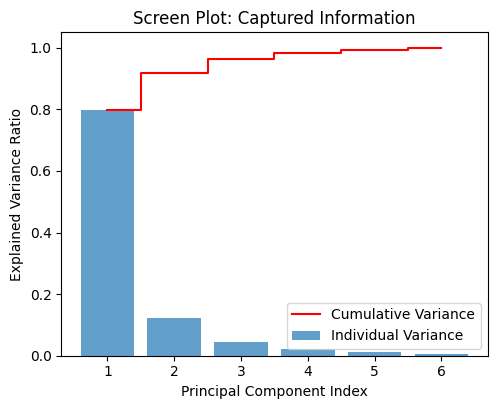

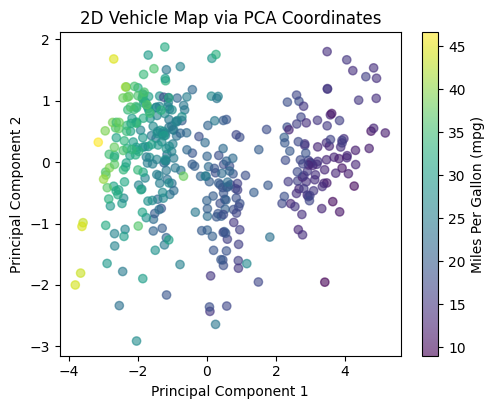

In [1]:
# 09_data-ex_04-1.py 19-06-2026
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
# 1. Load data from the official repository or standard mirror
# url = "https://githubusercontent.com"
# df = pd.read_csv(url) about
df = pd.read_csv("Auto.csv")
# 1 mpg
# 2 cylinders
# 3 displacement
# 4 horsepower
# 5 weight
# 6 acceleration
# per year,origin and name 
plt.rcParams['toolbar'] = 'None'
# 2. Drop missing values (the dataset stores missing horsepowers as '?')
df = df.replace('?', np.nan).dropna()
features = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']
X = df[features].astype(float).values

# 3. Standardize the data manually (Zero Mean, Unit Variance)
X_scaled = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

# 4. Generate the Covariance Matrix
cov_matrix = np.cov(X_scaled, rowvar=False)

# 5. Extract Principal Directions (Eigenvectors) & Strengths (Eigenvalues)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort from highest variance to lowest
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Calculate Explained Variance Proportion
variance_explained = eigenvalues / np.sum(eigenvalues)
print(f"Var expl.by PriCompScore1: {variance_explained[0]*100:.2f}%")
print(f"Var expl.by PriCompScore2: {variance_explained[1]*100:.2f}%")
print(f"Total var capt.by first two: {np.sum(variance_explained[:2])*100:.2f}%")

# Barplot
fig1, ax1 = plt.subplots(figsize=(5.5, 4.20))
ax1.bar(range(1, 7), variance_explained, alpha=0.7, align='center', label='Individual Variance')
ax1.step(range(1, 7), np.cumsum(variance_explained), where='mid', label='Cumulative Variance', color='red')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_xlabel('Principal Component Index')
ax1.legend(loc='best')
ax1.set_title('Screen Plot: Captured Information')
# plt.show()

fig2, ax2 = plt.subplots(figsize=(5.5, 4.20))
# Project the original data points onto the first two principal directions
X_projected = np.dot(X_scaled, eigenvectors[:, :2])
scatter_plot = ax2.scatter(X_projected[:, 0], X_projected[:, 1], alpha=0.6, c=df['mpg'], cmap='viridis')
cbar = fig2.colorbar(scatter_plot, ax=ax2)
cbar.set_label('Miles Per Gallon (mpg)')
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')
ax2.set_title('2D Vehicle Map via PCA Coordinates')
plt.show()


Var expl.by PriCompScore1: 79.80%
Var expl.by PriCompScore2: 12.14%
Total var capt.by first two: 91.95%


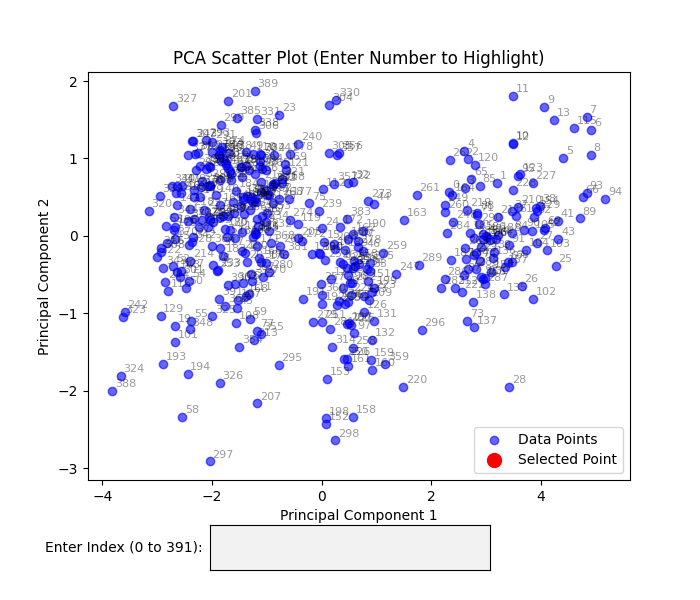

In [14]:
# AUFGABE 5 nach eigenem Ermessen 09_data-ex_04-2.py 19-06-2026
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import TextBox  # Import the TextBox widget
%matplotlib widget
# 1. Load data from the official repository or standard mirror
df = pd.read_csv("Auto.csv")

plt.rcParams['toolbar'] = 'None'
# 2. Drop missing values (the dataset stores missing horsepowers as '?')
df = df.replace('?', np.nan).dropna().reset_index(drop=True) # Reset index for clean numbering
features = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']
X = df[features].astype(float).values

# 3. Standardize the data manually (Zero Mean, Unit Variance)
X_scaled = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

# 4. Generate the Covariance Matrix
cov_matrix = np.cov(X_scaled, rowvar=False)

# 5. Extract Principal Directions (Eigenvectors) & Strengths (Eigenvalues)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort from highest variance to lowest
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Calculate Explained Variance Proportion
variance_explained = eigenvalues / np.sum(eigenvalues)
print(f"Var expl.by PriCompScore1: {variance_explained[0]*100:.2f}%")
print(f"Var expl.by PriCompScore2: {variance_explained[1]*100:.2f}%")
print(f"Total var capt.by first two: {np.sum(variance_explained[:2])*100:.2f}%")

# --- New Interactive PCA Scatter Plot (Figure 2) ---
# Project data onto the first two principal components
PC1 = X_scaled @ eigenvectors[:, 0]
PC2 = X_scaled @ eigenvectors[:, 1]

fig2, ax2 = plt.subplots(figsize=(7, 6))
plt.subplots_adjust(bottom=0.2) # Make room for the text box at the bottom

# Scatter plot of all points
scatter = ax2.scatter(PC1, PC2, alpha=0.6, color='blue', label='Data Points')
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')
ax2.set_title('PCA Scatter Plot (Enter Number to Highlight)')

# Numerate the points next to their dots (optional, can look crowded)
# For large datasets, you can comment this loop out and just rely on the text box
for i in range(len(PC1)):
    ax2.text(PC1[i] + 0.05, PC2[i] + 0.05, str(i), fontsize=8, alpha=0.4)

# Create an invisible or placeholder red dot for the highlighted selection
highlighted_dot, = ax2.plot([], [], 'ro', markersize=10, label='Selected Point')
ax2.legend(loc='best')

# Position the TextBox at the bottom of the window
ax_box = plt.axes([0.3, 0.05, 0.4, 0.075])
text_box = TextBox(ax_box, 'Enter Index (0 to {}): '.format(len(PC1)-1), initial="")

# Callback function that triggers when hitting 'Enter' in the text box
def submit(text):
    try:
        val = int(text)
        if 0 <= val < len(PC1):
            # Update the red dot location to the selected index coordinates
            highlighted_dot.set_data([PC1[val]], [PC2[val]])
            ax2.set_title(f'PCA Scatter Plot - Point {val} Selected')
            fig2.canvas.draw_idle() # Refresh the plot canvas safely
        else:
            ax2.set_title("Index out of range!")
            highlighted_dot.set_data([], [])
            fig2.canvas.draw_idle()
    except ValueError:
        ax2.set_title("Please enter a valid integer!")
        highlighted_dot.set_data([], [])
        fig2.canvas.draw_idle()

# Connect the submit event to our function
text_box.on_submit(submit)

plt.show()


Modus: Schnelles Laden von 'Auto-normalized.csv'...


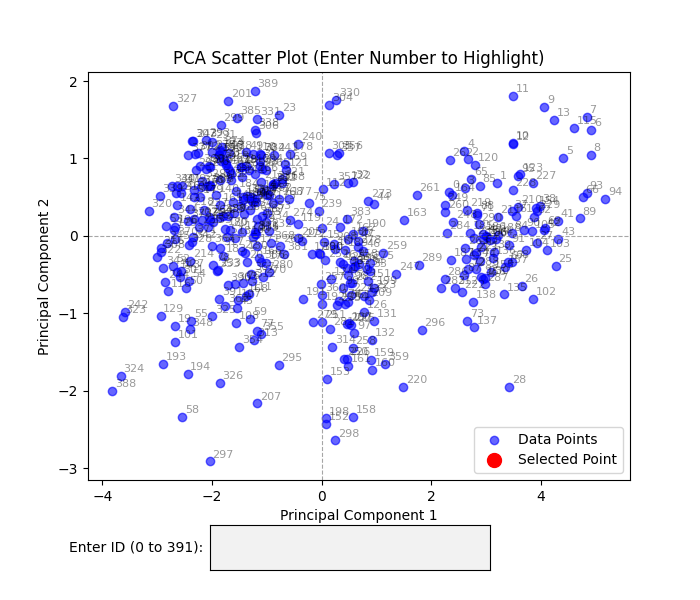

In [15]:
# AUFGABE 6 nach eigenem Ermessen 09_data-ex_04-4c.py 19-06-2026
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import TextBox
%matplotlib widget
# =====================================================================
# MODUS-AUSWAHL
# "GENERATE"  : Lädt Auto.csv, normalisiert, formatiert und speichert.
# "FAST_LOAD" : Lädt direkt die perfekt geordnete Auto-normalized.csv.
# =====================================================================
MODE = "FAST_LOAD" # "GENERATE" 

features = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']

if MODE == "GENERATE":
    print("Modus: Generiere normalisierte Daten...")
    # 1. Originaldaten laden und bereinigen
    df_original = pd.read_csv("Auto.csv")
    df_clean = df_original.replace('?', np.nan).dropna().reset_index(drop=True)
    
    # 2. Datenmatrix X extrahieren und manuell standardisieren
    X = df_clean[features].astype(float).values
    X_scaled = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
    
    # Trimmen auf exakt 6 Nachkommastellen (Matrix-Ebene)
    X_scaled = np.round(X_scaled, 6)
    
    # 3. Normalisierte Daten in neuem DataFrame speichern
    df_norm = pd.DataFrame(X_scaled, columns=features)
    
    # Die ID-Spalte einfügen und strikt auf 3 Zeichen rechtsbündig trimmen
    df_norm.insert(0, 'ID_Number', df_clean.index) 
    df_norm['ID_Number'] = df_norm['ID_Number'].apply(lambda x: f"{x:3d}")
    
    df_norm['name'] = df_clean['name'] # Namen für Textbox erhalten
    
    # Als "Auto-normalized.csv" abspeichern
    # % .6f erzwingt das Vorzeichen-Leerzeichen-Padding für perfekte Spalten-Symmetrie
    df_norm.to_csv("Auto-normalized.csv", index=False, float_format="% .6f")
    print("Datei 'Auto-normalized.csv' erfolgreich mit maximaler Ordnung gespeichert.")
    
    df = df_norm

elif MODE == "FAST_LOAD":
    print("Modus: Schnelles Laden von 'Auto-normalized.csv'...")
    df = pd.read_csv("Auto-normalized.csv")
    X_scaled = df[features].values

else:
    raise ValueError("Ungültiger Modus! Wählen Sie 'GENERATE' oder 'FAST_LOAD'.")


# =====================================================================
# LINEARE ALGEBRA PIPELINE (Kovarianzmatrix & Eigendecomposition)
# =====================================================================
plt.rcParams['toolbar'] = 'None'

# Daten sind zentriert/skaliert: Sigma = (X_scaled^T * X_scaled) / (n - 1)
cov_matrix = np.cov(X_scaled, rowvar=False)

# Eigenvektoren und Eigenwerte extrahieren
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sortierung nach maximaler Varianz (absteigend)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Erklärte Varianz berechnen
variance_explained = eigenvalues / np.sum(eigenvalues)
# =====================================================================
# VISUALISIERUNG
# =====================================================================
# --- Interactive PCA Scatter Plot (Figure 2) ---
# Projektion der normalisierten Daten auf die ersten beiden Hauptkomponenten
PC1 = X_scaled @ eigenvectors[:, 0]
PC2 = X_scaled @ eigenvectors[:, 1]

fig2, ax2 = plt.subplots(figsize=(7, 6))
plt.subplots_adjust(bottom=0.2) # Platz für die Textbox

# ---------------------------------------------------------------------
# INTEGRATION: Mathematisches Fadenkreuz (Crosshair bei PC1=0 und PC2=0)
# ---------------------------------------------------------------------
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax2.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
# ---------------------------------------------------------------------

# Scatter Plot aller Datenpunkte
scatter = ax2.scatter(PC1, PC2, alpha=0.6, color='blue', label='Data Points')
ax2.set_xlabel('Principal Component 1')
ax2.set_ylabel('Principal Component 2')
ax2.set_title('PCA Scatter Plot (Enter Number to Highlight)')

# Nummerierung neben den Punkten einblenden
for i in range(len(PC1)):
    ax2.text(PC1[i] + 0.05, PC2[i] + 0.05, str(int(df['ID_Number'].iloc[i])), fontsize=8, alpha=0.4)

# Platzhalter für den roten Highlight-Punkt
highlighted_dot, = ax2.plot([], [], 'ro', markersize=10, label='Selected Point')
ax2.legend(loc='best')

# Positionierung der TextBox am unteren Rand
ax_box = plt.axes([0.3, 0.05, 0.4, 0.075])
max_idx = int(df['ID_Number'].max())
text_box = TextBox(ax_box, f'Enter ID (0 to {max_idx}): ', initial="")

# Callback-Funktion für die Textbox (mit Leerzeichen-Berücksichtigung)
def submit(text):
    try:
        val = int(text)
        # astype(int) ignoriert führende Leerzeichen im ID
        matching_rows = df[df['ID_Number'].astype(int) == val]
        
        if not matching_rows.empty:
            row_idx = matching_rows.index[0] # Ersten passenden Index greifen
            # Roten Punkt auf die projizierten PC-Koordinaten setzen
            highlighted_dot.set_data([PC1[row_idx]], [PC2[row_idx]])
            
            car_name = df['name'].iloc[row_idx]
            ax2.set_title(f'ID {val}: {car_name}')
            fig2.canvas.draw_idle()
        else:
            ax2.set_title("ID nicht gefunden!")
            highlighted_dot.set_data([], [])
            fig2.canvas.draw_idle()
    except ValueError:
        ax2.set_title("Bitte eine gültige Ganzzahl eingeben!")
        highlighted_dot.set_data([], [])
        fig2.canvas.draw_idle()

text_box.on_submit(submit)
plt.show()


Evolution wird fortgesetzt: Lade 'Auto-reduced.csv'...


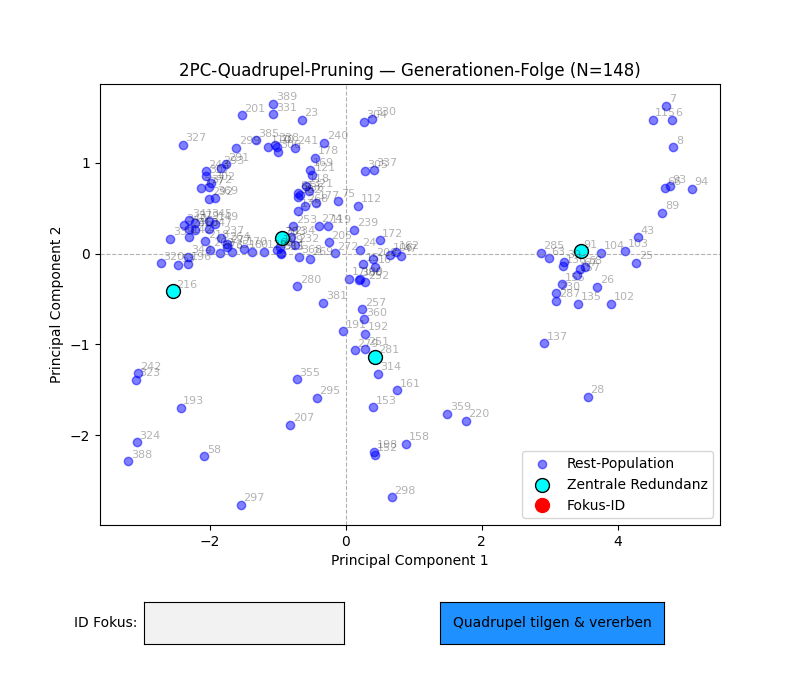

In [16]:
# AUFGABE 7 nach eigenem Ermessen09_data-ex_04-7.py 19-06-2026
# 09_2PC_pruning_grow.py 20-06-2026
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import TextBox, Button
import os
%matplotlib widget
# =====================================================================
# REINE GROW-ARCHITEKTUR (FORTPFLANZUNG)
# Suchreihenfolge: 1. Auto-reduced.csv (Fortsetzung) -> 2. Auto-normalized.csv (Start)
# =====================================================================
features = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']

if os.path.exists("Auto-reduced.csv"):
    print("Evolution wird fortgesetzt: Lade 'Auto-reduced.csv'...")
    df = pd.read_csv("Auto-reduced.csv")
else:
    if os.path.exists("Auto-normalized.csv"):
        print("Starte Evolution mit 'Auto-normalized.csv'...")
        df = pd.read_csv("Auto-normalized.csv")
    else:
        raise FileNotFoundError("Keine Datenbasis! Zuerst normalisierte Tabelle erzeugen.")

# Daten-Zustand einfrieren für den interaktiven Loop
current_df = df.copy()

# IDs für das mathematische Matching strippen und vereinheitlichen
current_df['ID_Number'] = current_df['ID_Number'].astype(int)

def compute_pca_and_quadruplet(df_data):
    """ Berechnet die aktuelle PCA und isoliert das repräsentativste Redundanz-Quadrupel """
    X_mat = df_data[features].values
    
    # Mathematische Re-Zentrierung auf den aktuellen Schwerpunkt der schrumpfenden Population
    X_mat_scaled = (X_mat - np.mean(X_mat, axis=0)) / np.std(X_mat, axis=0)
    
    cov_matrix = np.cov(X_mat_scaled, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    
    # Sortierung der Hauptachsen (Negentropie-Ordnung)
    idx = np.argsort(eigenvalues)[::-1]
    eigenvectors = eigenvectors[:, idx]
    
    # Projektion in den 2PC-Raum
    p1 = X_mat_scaled @ eigenvectors[:, 0]
    p2 = X_mat_scaled @ eigenvectors[:, 1]
    
    quadruplet_indices = []
    
    # Fadenkreuz-Quadranten-Masken
    quadrants = [
        (p1 >= 0) & (p2 >= 0),  # Q1 (+,+)
        (p1 < 0)  & (p2 >= 0),  # Q2 (-,+)
        (p1 < 0)  & (p2 < 0),  # Q3 (-,-)
        (p1 >= 0) & (p2 < 0)   # Q4 (+,-)
    ]
    
    for mask in quadrants:
        quad_idx = np.where(mask)[0]
        if len(quad_idx) == 0:
            continue
        
        # Lokaler euklidischer Vektorraum des Quadranten
        coords = np.column_stack((p1[quad_idx], p2[quad_idx]))
        
        min_mean_dist = float('inf')
        best_candidate = quad_idx[0]
        
        # Suche nach dem Punkt mit der geringsten mittleren Distanz (Zentralität/Redundanz)
        for i, idx_i in enumerate(quad_idx):
            dists = np.sqrt(np.sum((coords - coords[i])**2, axis=1))
            mean_dist = np.mean(dists)
            if mean_dist < min_mean_dist:
                min_mean_dist = mean_dist
                best_candidate = idx_i
                
        quadruplet_indices.append(best_candidate)
        
    return p1, p2, quadruplet_indices

# Initiale Ausmessung des Raumes
PC1, PC2, quad_idx_list = compute_pca_and_quadruplet(current_df)

# =====================================================================
# DAS EVOLUTIONÄRE INTERFACE
# =====================================================================
plt.rcParams['toolbar'] = 'None'
fig, ax = plt.subplots(figsize=(8, 7))
plt.subplots_adjust(bottom=0.25)

# Das unbestechliche Fadenkreuz
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

# Population und aktuelle Streichungskandidaten (Cyan)
scatter = ax.scatter(PC1, PC2, alpha=0.5, color='blue', label='Rest-Population')
quad_scatter = ax.scatter(PC1[quad_idx_list], PC2[quad_idx_list], color='cyan', edgecolors='black', s=100, label='Zentrale Redundanz')
highlighted_dot, = ax.plot([], [], 'ro', markersize=10, label='Fokus-ID')

# Dynamische Text-Etiketten
texts = []
def draw_labels():
    global texts
    for t in texts: t.remove()
    texts = []
    for i in range(len(PC1)):
        t = ax.text(PC1[i] + 0.04, PC2[i] + 0.04, str(current_df['ID_Number'].iloc[i]), fontsize=8, alpha=0.3)
        texts.append(t)

draw_labels()
ax.legend(loc='best')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_title(f'2PC-Quadrupel-Pruning — Generationen-Folge (N={len(current_df)})')

# Steuerungskonsole platziere am Boden
ax_box = plt.axes([0.18, 0.08, 0.25, 0.06])
text_box = TextBox(ax_box, 'ID Fokus: ', initial="")

ax_btn = plt.axes([0.55, 0.08, 0.28, 0.06])
btn_reduce = Button(ax_btn, 'Quadrupel tilgen & vererben', color='dodgerblue', hovercolor='skyblue')

# Textbox-Schnittstelle
def submit(text):
    try:
        val = int(text)
        matching_rows = current_df[current_df['ID_Number'] == val]
        if not matching_rows.empty:
            row_idx = matching_rows.index[0]
            idx_in_numpy = current_df.index.get_loc(row_idx)
            highlighted_dot.set_data([PC1[idx_in_numpy]], [PC2[idx_in_numpy]])
            ax.set_title(f"ID {val}: {current_df['name'].loc[row_idx]}")
            fig.canvas.draw_idle()
        else:
            ax.set_title("ID in aktueller Generation erloschen!")
            fig.canvas.draw_idle()
    except ValueError:
        ax.set_title("Gültige ID eingeben!")
        fig.canvas.draw_idle()

# Die evolutionäre Vererbungskette (Button-Klick)
def reduce_population(event):
    global current_df, PC1, PC2, quad_idx_list
    
    if len(current_df) <= 4:
        ax.set_title("Kritische Mutationsgrenze erreicht (N <= 4)!")
        fig.canvas.draw_idle()
        return

    # Extrahiere IDs der auszuscheidenden Individuen
    dropped_ids = current_df['ID_Number'].iloc[quad_idx_list].values
    print(f"Tilge Generationen-Überfluss: IDs {[int(x) for x in dropped_ids]}")
    
    # Exmission aus dem Genpool
    current_df = current_df.drop(current_df.index[quad_idx_list]).reset_index(drop=True)
    
    # Sofortige Neuanpassung des Raumes an die verbliebene Population
    PC1, PC2, quad_idx_list = compute_pca_and_quadruplet(current_df)
    
    # Grafisches Update der veränderten Matrix
    scatter.set_offsets(np.column_stack((PC1, PC2)))
    quad_scatter.set_offsets(np.column_stack((PC1[quad_idx_list], PC2[quad_idx_list])))
    highlighted_dot.set_data([], []) 
    
    draw_labels()
    
    # Skalierung dynamisch nachziehen
    ax.set_xlim(PC1.min() - 0.5, PC1.max() + 0.5)
    ax.set_ylim(PC2.min() - 0.5, PC2.max() + 0.5)
    ax.set_title(f'2PC-Quadrupel-Pruning — Generationen-Folge (N={len(current_df)})')
    
    # Speichern unter strikter Wahrung der negenentropischen Formatierung
    df_save = current_df.copy()
    df_save['ID_Number'] = df_save['ID_Number'].apply(lambda x: f"{int(x):3d}")
    df_save.to_csv("Auto-reduced.csv", index=False, float_format="% .6f")
    fig.canvas.draw_idle()

text_box.on_submit(submit)
btn_reduce.on_clicked(reduce_population)

plt.show()


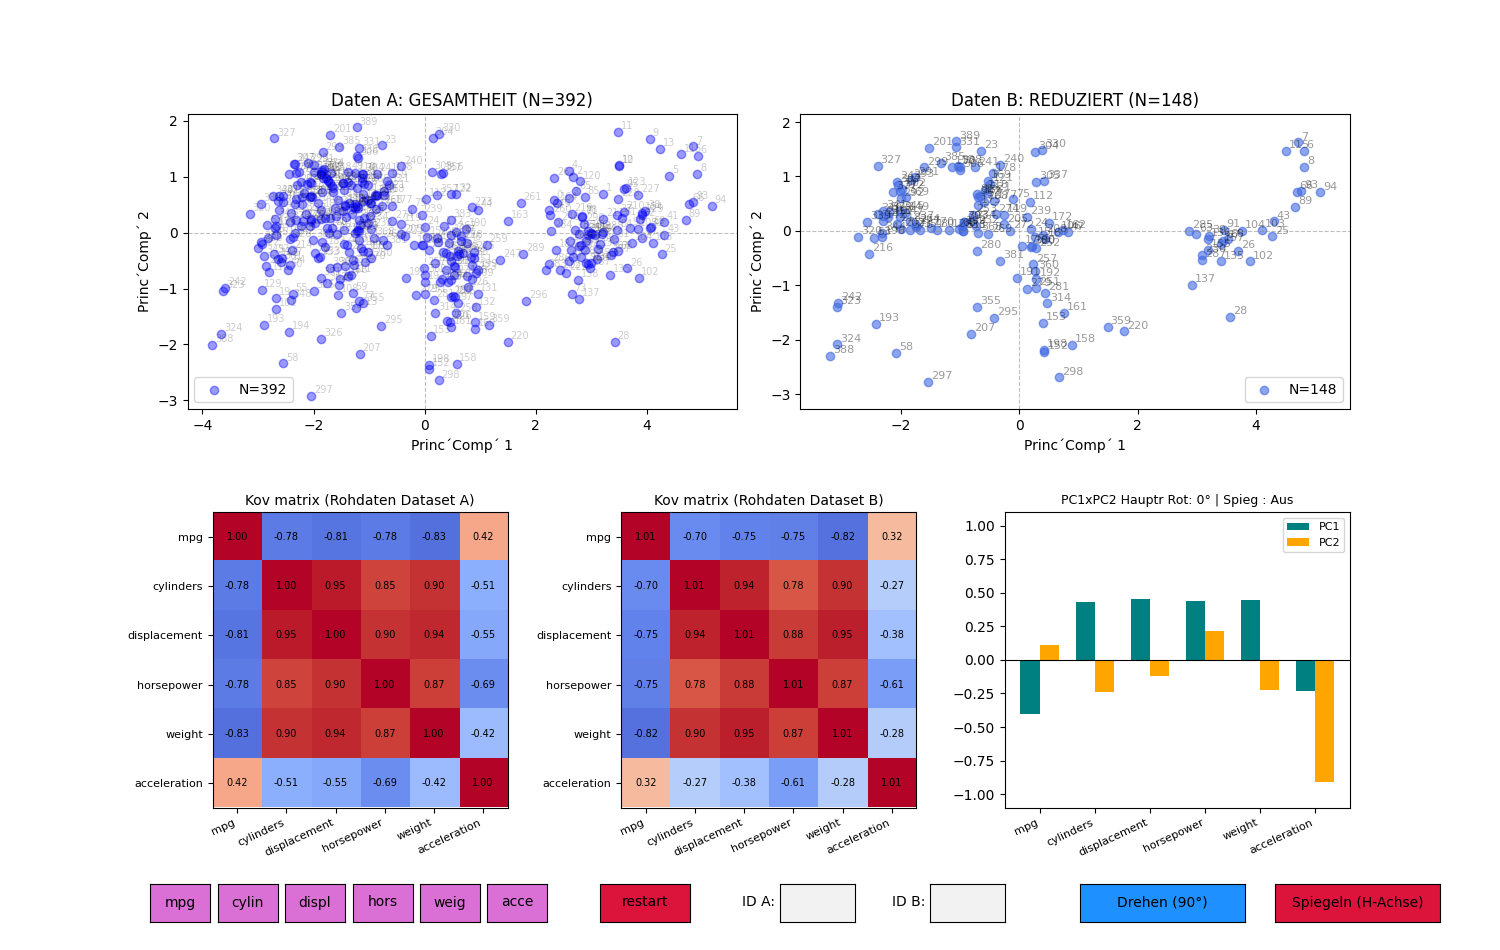

In [17]:
# AUFGABE 8 nach eigenem Ermessen 09_data-ex_04_New-Twin_06d.py (20-06-2026)
# =====================================================================
# TEIL 1: DATA PARSING, PCA CALCULATION & GRID LAYOUT (ARTIST FIX)
# =====================================================================
import os
import matplotlib.pyplot as plt
from matplotlib.widgets import Button, TextBox
import numpy as np
import pandas as pd
%matplotlib widget
# Alle verfügbaren Features und deren Kurznamen für das UI
ALL_FEATURES = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
]
FEATURE_LABELS = ["mpg", "cylin", "displ", "hors", "weig", "acce"]

file_orig = "Auto-normalized.csv"
file_redu = "Auto-reduced.csv"

if not os.path.exists(file_orig) or not os.path.exists(file_redu):
    raise FileNotFoundError(
        "Auto-normalized.csv und/oder Auto-reduced.csv fehlen"
    )

df_raw_orig = pd.read_csv(file_orig, dtype=str)
df_raw_redu = pd.read_csv(file_redu, dtype=str)


def clean_and_parse(df_raw):
    df_clean = pd.DataFrame()
    df_clean["ID_Number"] = df_raw["ID_Number"].str.strip().astype(int)
    df_clean["name"] = df_raw["name"].astype(str)
    for feat in ALL_FEATURES:
        df_clean[feat] = df_raw[feat].str.strip().astype(float)
    return df_clean


df_orig = clean_and_parse(df_raw_orig)
df_redu = clean_and_parse(df_raw_redu)

# Dynamischer Zustand der Feature-Auswahl
feature_states = {feat: True for feat in ALL_FEATURES}

# Geometrie-Zustände für Dataset B
rotation_state = 0
mirror_state = 1

# Schnelle Zeilen-Indizes für den Fokus
idx_focus_A = None
idx_focus_B = None

# SELEKTIVER RIEGEL für die Merkmalsknöpfe
filter_lock = False

# Globale Variablen für berechnete Werte
PC1_orig, PC2_orig = None, None
PC1_base_redu, PC2_base_redu = None, None
cov_orig, cov_redu = None, None
evecs_redu, evals_redu = None, None
PC1_redu, PC2_redu = None, None

# Globale Referenz für das Scatter-Objekt zur fehlerfreien Transformation
scatter_B = None


def recalculate_pca():
    """Berechnet die PCA-Projektionen basierend auf aktiven Features"""
    global PC1_orig, PC2_orig, PC1_base_redu, PC2_base_redu
    global cov_orig, cov_redu, evecs_redu, evals_redu

    active_feats = [f for f in ALL_FEATURES if feature_states[f]]

    if len(active_feats) < 2:
        return False

    # Berechnung für Gesamtheit A
    X_A = df_orig[active_feats].values
    X_A_scaled = (X_A - np.mean(X_A, axis=0)) / np.std(X_A, axis=0)
    cov_orig = np.cov(X_A_scaled, rowvar=False)
    evals_A, evecs_A = np.linalg.eigh(cov_orig)
    idx_A = np.argsort(evals_A)[::-1]
    evecs_A = evecs_A[:, idx_A]
    PC1_orig = X_A_scaled @ evecs_A[:, 0]
    PC2_orig = X_A_scaled @ evecs_A[:, 1]

    # Berechnung für Reduziert B
    X_B = df_redu[active_feats].values
    X_B_scaled = (X_B - np.mean(X_B, axis=0)) / np.std(X_B, axis=0)
    cov_redu = np.cov(X_B_scaled, rowvar=False)
    evals_B, evecs_B = np.linalg.eigh(cov_redu)
    idx_B = np.argsort(evals_B)[::-1]
    evals_redu = evals_B[idx_B]
    evecs_redu = evecs_B[:, idx_B]
    PC1_base_redu = X_B_scaled @ evecs_redu[:, 0]
    PC2_base_redu = X_B_scaled @ evecs_redu[:, 1]

    return True


recalculate_pca()
PC1_redu = PC1_base_redu.copy()
PC2_redu = PC2_base_redu.copy()

# INTERFACE LAYOUT
plt.rcParams["toolbar"] = "None"
fig = plt.figure(figsize=(15, 9.5))

ax_left = plt.subplot2grid((2, 6), (0, 0), colspan=3)
ax_right = plt.subplot2grid((2, 6), (0, 3), colspan=3)
ax_cov_A = plt.subplot2grid((2, 6), (1, 0), colspan=2)
ax_cov_B = plt.subplot2grid((2, 6), (1, 2), colspan=2)
ax_load = plt.subplot2grid((2, 6), (1, 4), colspan=2)

plt.subplots_adjust(bottom=0.15, hspace=0.35, wspace=0.45)
highlight_orig = None
highlight_redu = None
###########################################################
# =====================================================================
# TEIL 2: DRAW FUNKTION & INTERAKTIVE WIDGETS (PROT_GEOMETRY)
# =====================================================================


def update_plots(full_refresh=True):
    """Aktualisiert die Plots flackerfrei und ohne ArtistList-Kollisionen"""
    global PC1_redu, PC2_redu, highlight_orig, highlight_redu, scatter_B

    active_feats = [f for f in ALL_FEATURES if feature_states[f]]

    # 1. GEOMETRIE-TRANSFORMATION FÜR DATASET B
    if rotation_state == 0:
        p1, p2 = PC1_base_redu.copy(), PC2_base_redu.copy()
        v1 = evecs_redu[:, 0].copy() if evecs_redu is not None else None
        v2 = evecs_redu[:, 1].copy() if evecs_redu is not None else None
    elif rotation_state == 1:
        p1, p2 = PC2_base_redu.copy(), -PC1_base_redu.copy()
        v1 = evecs_redu[:, 1].copy()
        v2 = -evecs_redu[:, 0].copy()
    elif rotation_state == 2:
        p1, p2 = -PC1_base_redu.copy(), -PC2_base_redu.copy()
        v1 = -evecs_redu[:, 0].copy()
        v2 = -evecs_redu[:, 1].copy()
    elif rotation_state == 3:
        p1, p2 = -PC2_base_redu.copy(), PC1_base_redu.copy()
        v1 = -evecs_redu[:, 1].copy()
        v2 = evecs_redu[:, 0].copy()

    PC1_redu = p1 * mirror_state
    PC2_redu = p2
    if v1 is not None:
        v1 = v1 * mirror_state

    # --- PLOTS RENDERN ---
    if full_refresh:
        ax_left.cla()
        ax_right.cla()

        for ax in [ax_left, ax_right]:
            ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
            ax.axvline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
            ax.set_xlabel("Princ´Comp´ 1")
            ax.set_ylabel("Princ´Comp´ 2")

        # Scatter Daten A
        ax_left.scatter(
            PC1_orig, PC2_orig, alpha=0.4, color="blue", label=f"N={len(df_orig)}"
        )
        (highlight_orig,) = ax_left.plot([], [], "ro", markersize=10, zorder=5)
        ax_left.set_title(f"Daten A: GESAMTHEIT (N={len(df_orig)})")
        ax_left.legend(loc="lower left")

        for i in range(len(PC1_orig)):
            ax_left.text(
                PC1_orig[i] + 0.05, PC2_orig[i] + 0.05,
                str(df_orig["ID_Number"].iloc[i]), fontsize=7, alpha=0.2
            )

        # Scatter Daten B direkt der globalen Referenz zuweisen (Verhindert Artist-Fehler)
        scatter_B = ax_right.scatter(
            PC1_redu, PC2_redu, alpha=0.6, color="royalblue", label=f"N={len(df_redu)}"
        )
        (highlight_redu,) = ax_right.plot([], [], "ro", markersize=10, zorder=5)
        ax_right.set_title(f"Daten B: REDUZIERT (N={len(df_redu)})")
        ax_right.legend(loc="lower right")

        for i in range(len(PC1_redu)):
            ax_right.text(
                PC1_redu[i] + 0.05, PC2_redu[i] + 0.05,
                str(df_redu["ID_Number"].iloc[i]), fontsize=8, alpha=0.4
            )

        # --- MATRIZEN REFRESH ---
        ax_cov_A.cla()
        ax_cov_B.cla()

        ax_cov_A.imshow(cov_orig, cmap="coolwarm", vmin=-1, vmax=1)
        ax_cov_A.set_title("Kov matrix (Rohdaten Dataset A)", fontsize=10)
        ax_cov_A.set_xticks(range(len(active_feats)))
        ax_cov_A.set_yticks(range(len(active_feats)))
        ax_cov_A.set_xticklabels(active_feats, rotation=25, ha="right", fontsize=8)
        ax_cov_A.set_yticklabels(active_feats, fontsize=8)
        for i in range(len(active_feats)):
            for j in range(len(active_feats)):
                ax_cov_A.text(
                    j, i, f"{cov_orig[i, j]:.2f}", ha="center", va="center", color="black", fontsize=7
                )

        ax_cov_B.imshow(cov_redu, cmap="coolwarm", vmin=-1, vmax=1)
        ax_cov_B.set_title("Kov matrix (Rohdaten Dataset B)", fontsize=10)
        ax_cov_B.set_xticks(range(len(active_feats)))
        ax_cov_B.set_yticks(range(len(active_feats)))
        ax_cov_B.set_xticklabels(active_feats, rotation=25, ha="right", fontsize=8)
        ax_cov_B.set_yticklabels(active_feats, fontsize=8)
        for i in range(len(active_feats)):
            for j in range(len(active_feats)):
                ax_cov_B.text(
                    j, i, f"{cov_redu[i, j]:.2f}", ha="center", va="center", color="black", fontsize=7
                )
    else:
        # RASANTE, FEHLERFREIE GEOMETRIE-TRANSFORMATION ÜBER DIREKTREFERENZ
        if scatter_B is not None:
            scatter_B.set_offsets(np.column_stack((PC1_redu, PC2_redu)))

    # --- ULTRASCHNELLER FOKUS-SYNC ÜBER DIREKTINDEX ---
    if idx_focus_A is not None:
        highlight_orig.set_data([PC1_orig[idx_focus_A]], [PC2_orig[idx_focus_A]])
        ax_left.set_title(f"A: ID {df_orig['ID_Number'].iloc[idx_focus_A]} | {df_orig['name'].iloc[idx_focus_A]}")

    if idx_focus_B is not None:
        highlight_redu.set_data([PC1_redu[idx_focus_B]], [PC2_redu[idx_focus_B]])
        ax_right.set_title(f"B: ID {df_redu['ID_Number'].iloc[idx_focus_B]} | {df_redu['name'].iloc[idx_focus_B]}")

    # --- BALKENGRAFIK (LOADINGS) ---
    ax_load.cla()
    x_indices = np.arange(len(active_feats))
    width = 0.35
    ax_load.bar(x_indices - width / 2, v1, width, color="teal", label="PC1")
    ax_load.bar(x_indices + width / 2, v2, width, color="orange", label="PC2")
    ax_load.axhline(0, color="black", linewidth=0.8, linestyle="-")
    ax_load.set_xticks(x_indices)
    ax_load.set_xticklabels(active_feats, rotation=25, ha="right", fontsize=8)
    ax_load.set_ylim(-1.1, 1.1)
    ax_load.legend(loc="upper right", fontsize=8)

    m_str = "Ein" if mirror_state == -1 else "Aus"
    ax_load.set_title(f"PC1xPC2 Hauptr Rot: {rotation_state*90}° | Spieg : {m_str}", fontsize=9)

    ax_right.set_xlim(PC1_redu.min() - 0.5, PC1_redu.max() + 0.5)
    ax_right.set_ylim(PC2_redu.min() - 0.5, PC2_redu.max() + 0.5)
    fig.canvas.draw_idle()


def silence_hover(widget_button):
    widget_button.hovercolor = widget_button.color
    widget_button._motion_notify = lambda event: None


# =====================================================================
# WIDGETS & CALL-BACKS
# =====================================================================
buttons_toggle = {}
button_axes = []

x_start = 0.10
for idx, (feat, label) in enumerate(zip(ALL_FEATURES, FEATURE_LABELS)):
    ax_btn = plt.axes([x_start + (idx * 0.045), 0.03, 0.04, 0.04])
    btn = Button(ax_btn, label, color="orchid")
    silence_hover(btn)
    buttons_toggle[feat] = btn
    button_axes.append(ax_btn)


def make_toggle_callback(f_name):
    def callback(event):
        global filter_lock
        if filter_lock: return
        if sum(feature_states.values()) <= 2 and feature_states[f_name]: return

        filter_lock = True
        feature_states[f_name] = not feature_states[f_name]
        new_color = "orchid" if feature_states[f_name] else "lightgray"
        buttons_toggle[f_name].color = new_color
        buttons_toggle[f_name].hovercolor = new_color
        buttons_toggle[f_name].ax.set_facecolor(new_color)
        
        if recalculate_pca():
            update_plots(full_refresh=True)
        filter_lock = False
    return callback


for feat in ALL_FEATURES:
    buttons_toggle[feat].on_clicked(make_toggle_callback(feat))

ax_btn_restart = plt.axes([0.40, 0.03, 0.06, 0.04])
btn_restart = Button(ax_btn_restart, "restart", color="crimson")
silence_hover(btn_restart)


def on_restart(event):
    global rotation_state, mirror_state, filter_lock, idx_focus_A, idx_focus_B
    if filter_lock: return
    filter_lock = True
    rotation_state = 0
    mirror_state = 1
    idx_focus_A = None
    idx_focus_B = None
    for f in ALL_FEATURES:
        feature_states[f] = True
        buttons_toggle[f].color = "orchid"
        buttons_toggle[f].hovercolor = "orchid"
        buttons_toggle[f].ax.set_facecolor("orchid")
    recalculate_pca()
    update_plots(full_refresh=True)
    filter_lock = False


btn_restart.on_clicked(on_restart)

ax_box_l = plt.axes([0.52, 0.03, 0.05, 0.04])
text_box_l = TextBox(ax_box_l, "ID A: ", initial="")

ax_box_r = plt.axes([0.62, 0.03, 0.05, 0.04])
text_box_r = TextBox(ax_box_r, "ID B: ", initial="")


def submit_left(text):
    global idx_focus_A
    try:
        val = int(text)
        match = df_orig[df_orig["ID_Number"] == val]
        if not match.empty:
            idx_focus_A = df_orig.index[df_orig["ID_Number"] == val].tolist()
            update_plots(full_refresh=True)
        else:
            idx_focus_A = None
            update_plots(full_refresh=False)
    except Exception:
        idx_focus_A = None
        update_plots(full_refresh=False)


def submit_right(text):
    global idx_focus_B
    try:
        val = int(text)
        match = df_redu[df_redu["ID_Number"] == val]
        if not match.empty:
            idx_focus_B = df_redu.index[df_redu["ID_Number"] == val].tolist()
            update_plots(full_refresh=True)
        else:
            idx_focus_B = None
            update_plots(full_refresh=False)
    except Exception:
        idx_focus_B = None
        update_plots(full_refresh=False)


text_box_l.on_submit(submit_left)
text_box_r.on_submit(submit_right)

ax_btn_rot = plt.axes([0.72, 0.03, 0.11, 0.04])
btn_rotate = Button(ax_btn_rot, "Drehen (90°)", color="dodgerblue")
silence_hover(btn_rotate)

ax_btn_mir = plt.axes([0.85, 0.03, 0.11, 0.04])
btn_mirror = Button(ax_btn_mir, "Spiegeln (H-Achse)", color="crimson")
silence_hover(btn_mirror)


def rotate_reduktion(event):
    global rotation_state
    rotation_state = (rotation_state + 1) % 4
    update_plots(full_refresh=False)


def mirror_reduktion(event):
    global mirror_state
    mirror_state = -1 if mirror_state == 1 else 1
    update_plots(full_refresh=False)


btn_rotate.on_clicked(rotate_reduktion)
btn_mirror.on_clicked(mirror_reduktion)

update_plots(full_refresh=True)
plt.show()



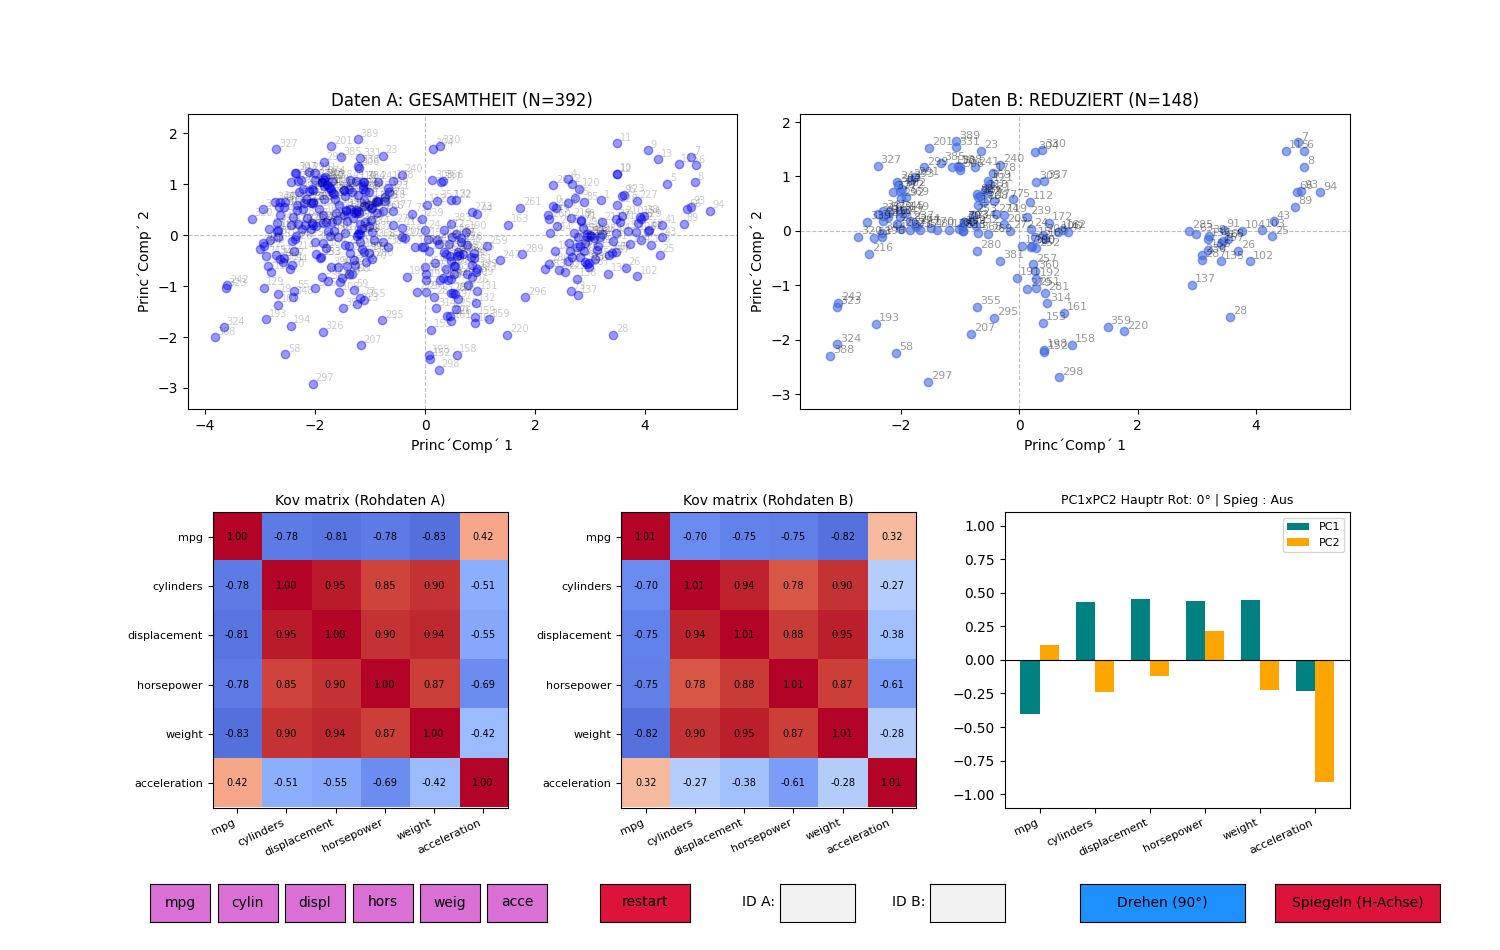

In [21]:
# AUFGABE 9 nach eigenem Ermessen 09_data-ex_04_New-Twin_07.py (20-06-2026)
# =====================================================================
# TEIL 1 VON 3: DATA PARSING & REITER-DIMETRIE (REVISITED)
# =====================================================================
import os
import matplotlib.pyplot as plt
from matplotlib.widgets import Button, TextBox
import numpy as np
import pandas as pd
%matplotlib widget

ALL_FEATURES = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
]
FEATURE_LABELS = ["mpg", "cylin", "displ", "hors", "weig", "acce"]

file_orig = "Auto-normalized.csv"
file_redu = "Auto-reduced.csv"

if not os.path.exists(file_orig) or not os.path.exists(file_redu):
    raise FileNotFoundError(
        "Auto-normalized.csv und/oder Auto-reduced.csv fehlen"
    )

df_raw_orig = pd.read_csv(file_orig, dtype=str)
df_raw_redu = pd.read_csv(file_redu, dtype=str)


def clean_and_parse(df_raw):
    df_clean = pd.DataFrame()
    df_clean["ID_Number"] = df_raw["ID_Number"].str.strip().astype(int)
    df_clean["name"] = df_raw["name"].astype(str)
    for feat in ALL_FEATURES:
        df_clean[feat] = df_raw[feat].str.strip().astype(float)
    return df_clean


df_orig = clean_and_parse(df_raw_orig)
df_redu = clean_and_parse(df_raw_redu)

# Zustandskapselung
feature_states = {feat: True for feat in ALL_FEATURES}
rotation_state = 0
mirror_state = 1

idx_focus_A = None
idx_focus_B = None
filter_lock = False

# Globale Variablen für PCA und Geometrie
PC1_orig, PC2_orig = None, None
PC1_base_redu, PC2_base_redu = None, None
cov_orig, cov_redu = None, None
evecs_redu, evals_redu = None, None
PC1_redu, PC2_redu = None, None
scatter_B = None

is_3d_mode = False
X3D_orig, Y3D_orig = None, None
X3D_redu_base, Y3D_redu_base = None, None
evecs_A_raw, evals_A_raw = None, None
evecs_B_raw, evals_B_raw = None, None


def project_dimetric_core(x_3d, y_3d, z_3d):
    """Das mathematische Herzstück: Wahre Reiterperspektive von oben-vorne"""
    alpha = np.radians(7.0)
    beta = np.radians(42.0)
    kx, ky, kz = 0.95, 1.0, 0.5

    x_2d = x_3d * kx * np.cos(alpha) - z_3d * kz * np.cos(beta)
    y_2d = y_3d * ky - x_3d * kx * np.sin(alpha) - z_3d * kz * np.sin(beta)
    return x_2d, y_2d


def project_dimetric(X_scaled):
    return project_dimetric_core(X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2])


def recalculate_pca():
    global PC1_orig, PC2_orig, PC1_base_redu, PC2_base_redu, is_3d_mode
    global cov_orig, cov_redu, evecs_redu, evals_redu
    global X3D_orig, Y3D_orig, X3D_redu_base, Y3D_redu_base
    global evecs_A_raw, evals_A_raw, evecs_B_raw, evals_B_raw

    active_feats = [f for f in ALL_FEATURES if feature_states[f]]
    if len(active_feats) < 2:
        return False

    is_3d_mode = len(active_feats) == 3

    # Datensatz A
    X_A = df_orig[active_feats].values
    X_A_scaled = (X_A - np.mean(X_A, axis=0)) / np.std(X_A, axis=0)
    cov_orig = np.cov(X_A_scaled, rowvar=False)
    evals_A, evecs_A = np.linalg.eigh(cov_orig)
    idx_A = np.argsort(evals_A)[::-1]
    evals_A_raw = evals_A[idx_A]
    evecs_A_raw = evecs_A[:, idx_A]

    # Datensatz B
    X_B = df_redu[active_feats].values
    X_B_scaled = (X_B - np.mean(X_B, axis=0)) / np.std(X_B, axis=0)
    cov_redu = np.cov(X_B_scaled, rowvar=False)
    evals_B, evecs_B = np.linalg.eigh(cov_redu)
    idx_B = np.argsort(evals_B)[::-1]
    evals_redu = evals_B[idx_B]
    evecs_redu = evecs_B[:, idx_B]
    evals_B_raw = evals_B[idx_B]
    evecs_B_raw = evecs_B[:, idx_B]

    if is_3d_mode:
        X3D_orig, Y3D_orig = project_dimetric(X_A_scaled)
        X3D_redu_base, Y3D_redu_base = project_dimetric(X_B_scaled)
    else:
        PC1_orig = X_A_scaled @ evecs_A_raw[:, 0]
        PC2_orig = X_A_scaled @ evecs_A_raw[:, 1]
        PC1_base_redu = X_B_scaled @ evecs_redu[:, 0]
        PC2_base_redu = X_B_scaled @ evecs_redu[:, 1]

    return True


recalculate_pca()
PC1_redu = X3D_redu_base.copy() if is_3d_mode else PC1_base_redu.copy()
PC2_redu = Y3D_redu_base.copy() if is_3d_mode else PC2_base_redu.copy()

plt.rcParams["toolbar"] = "None"
fig = plt.figure(figsize=(15, 9.5))

ax_left = plt.subplot2grid((2, 6), (0, 0), colspan=3)
ax_right = plt.subplot2grid((2, 6), (0, 3), colspan=3)
ax_cov_A = plt.subplot2grid((2, 6), (1, 0), colspan=2)
ax_cov_B = plt.subplot2grid((2, 6), (1, 2), colspan=2)
ax_load = plt.subplot2grid((2, 6), (1, 4), colspan=2)

plt.subplots_adjust(bottom=0.15, hspace=0.35, wspace=0.45)
highlight_orig = None
highlight_redu = None

# =====================================================================
# TEIL 2 VON 3: GRAPHICAL ENGINE & CRASH-PROOF VECTOR RENDERING
# =====================================================================


def draw_eigen_vectors(ax, evecs, evals, is_dataset_b=False):
    """Projiziert die Eigenvektoren fehlerfrei in das dimetrische Raumbild"""
    if not is_3d_mode or evecs is None:
        return

    # Proportional-Skalierung über die Standardabweichung der PCA
    len_pc1 = np.sqrt(evals[0]) * 1.5
    len_pc2 = np.sqrt(evals[1]) * 1.5

    v1_3d = evecs[:, 0] * len_pc1
    v2_3d = evecs[:, 1] * len_pc2

    # Geometrische Live-Transformationen für das rechte Fenster B
    if is_dataset_b:
        if rotation_state == 1:
            v1_3d, v2_3d = v2_3d, -v1_3d
        elif rotation_state == 2:
            v1_3d, v2_3d = -v1_3d, -v2_3d
        elif rotation_state == 3:
            v1_3d, v2_3d = -v2_3d, v1_3d
        v1_3d = v1_3d * mirror_state

    # 3D-Endpunkte exakt über die identische Reiter-Matrix in 2D wandeln
    v1_2d_x, v1_2d_y = project_dimetric_core(v1_3d[0], v1_3d[1], v1_3d[2])
    v2_2d_x, v2_2d_y = project_dimetric_core(v2_3d[0], v2_3d[1], v2_3d[2])

    # Plotten der Vektorpfeile ausgehend vom Zentrum (0,0)
    ax.arrow(
        0, 0, v1_2d_x, v1_2d_y,
        color="teal", width=0.03, head_width=0.12, zorder=10, label="PC1 Achse"
    )
    ax.arrow(
        0, 0, v2_2d_x, v2_2d_y,
        color="orange", width=0.03, head_width=0.12, zorder=10, label="PC2 Achse"
    )


def update_plots(full_refresh=True):
    global PC1_redu, PC2_redu, highlight_orig, highlight_redu, scatter_B

    active_feats = [f for f in ALL_FEATURES if feature_states[f]]

    if is_3d_mode:
        if rotation_state == 0:
            p1, p2 = X3D_redu_base.copy(), Y3D_redu_base.copy()
        elif rotation_state == 1:
            p1, p2 = Y3D_redu_base.copy(), -X3D_redu_base.copy()
        elif rotation_state == 2:
            p1, p2 = -X3D_redu_base.copy(), -Y3D_redu_base.copy()
        elif rotation_state == 3:
            p1, p2 = -Y3D_redu_base.copy(), X3D_redu_base.copy()
        p1 = p1 * mirror_state
        x_plot_A, y_plot_A = X3D_orig, Y3D_orig
        x_plot_B, y_plot_B = p1, p2
    else:
        if rotation_state == 0:
            p1, p2 = PC1_base_redu.copy(), PC2_base_redu.copy()
            v1 = evecs_redu[:, 0].copy() if evecs_redu is not None else None
            v2 = evecs_redu[:, 1].copy() if evecs_redu is not None else None
        elif rotation_state == 1:
            p1, p2 = PC2_base_redu.copy(), -PC1_base_redu.copy()
            v1, v2 = evecs_redu[:, 1].copy(), -evecs_redu[:, 0].copy()
        elif rotation_state == 2:
            p1, p2 = -PC1_base_redu.copy(), -PC2_base_redu.copy()
            v1, v2 = -evecs_redu[:, 0].copy(), -evecs_redu[:, 1].copy()
        elif rotation_state == 3:
            p1, p2 = -PC2_base_redu.copy(), PC1_base_redu.copy()
            v1, v2 = -evecs_redu[:, 1].copy(), evecs_redu[:, 0].copy()
        p1 = p1 * mirror_state
        if v1 is not None:
            v1 = v1 * mirror_state
        x_plot_A, y_plot_A = PC1_orig, PC2_orig
        x_plot_B, y_plot_B = p1, p2

    PC1_redu, PC2_redu = x_plot_B, y_plot_B

    if full_refresh:
        ax_left.cla()
        ax_right.cla()

        for ax in [ax_left, ax_right]:
            ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
            ax.axvline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
            ax.set_xlabel("Dimetrisch X" if is_3d_mode else "Princ´Comp´ 1")
            ax.set_ylabel("Dimetrisch Y" if is_3d_mode else "Princ´Comp´ 2")

        ax_left.scatter(x_plot_A, y_plot_A, alpha=0.4, color="blue", label=f"N={len(df_orig)}")
        (highlight_orig,) = ax_left.plot([], [], "ro", markersize=10, zorder=12)
        title_A = "3D REITER-DIMETRIE" if is_3d_mode else "GESAMTHEIT"
        ax_left.set_title(f"Daten A: {title_A} (N={len(df_orig)})")
        
        for i in range(len(x_plot_A)):
            ax_left.text(x_plot_A[i] + 0.05, y_plot_A[i] + 0.05, str(df_orig["ID_Number"].iloc[i]), fontsize=7, alpha=0.2)

        scatter_B = ax_right.scatter(x_plot_B, y_plot_B, alpha=0.6, color="royalblue", label=f"N={len(df_redu)}")
        (highlight_redu,) = ax_right.plot([], [], "ro", markersize=10, zorder=12)
        title_B = "3D REITER-DIMETRIE" if is_3d_mode else "REDUZIERT"
        ax_right.set_title(f"Daten B: {title_B} (N={len(df_redu)})")

        for i in range(len(x_plot_B)):
            ax_right.text(x_plot_B[i] + 0.05, y_plot_B[i] + 0.05, str(df_redu["ID_Number"].iloc[i]), fontsize=8, alpha=0.4)

        if is_3d_mode:
            draw_eigen_vectors(ax_left, evecs_A_raw, evals_A_raw, is_dataset_b=False)
            draw_eigen_vectors(ax_right, evecs_B_raw, evals_B_raw, is_dataset_b=True)
            ax_left.legend(loc="lower left")
            ax_right.legend(loc="lower right")

        ax_cov_A.cla()
        ax_cov_B.cla()
        for ax, cov, name in [(ax_cov_A, cov_orig, "A"), (ax_cov_B, cov_redu, "B")]:
            ax.imshow(cov, cmap="coolwarm", vmin=-1, vmax=1)
            ax.set_title(f"Kov matrix (Rohdaten {name})", fontsize=10)
            ax.set_xticks(range(len(active_feats)))
            ax.set_yticks(range(len(active_feats)))
            ax.set_xticklabels(active_feats, rotation=25, ha="right", fontsize=8)
            ax.set_yticklabels(active_feats, fontsize=8)
            for i in range(len(active_feats)):
                for j in range(len(active_feats)):
                    ax.text(j, i, f"{cov[i, j]:.2f}", ha="center", va="center", color="black", fontsize=7)
    else:
        if scatter_B is not None:
            scatter_B.set_offsets(np.column_stack((x_plot_B, y_plot_B)))
            if is_3d_mode:
                # Alte Vektorpfeile beim schnellen Drehen sauber abräumen
                for p in list(ax_right.patches): p.remove()
                draw_eigen_vectors(ax_right, evecs_B_raw, evals_B_raw, is_dataset_b=True)

    if idx_focus_A is not None:
        highlight_orig.set_data([x_plot_A[idx_focus_A]], [y_plot_A[idx_focus_A]])
        ax_left.set_title(f"A: ID {df_orig['ID_Number'].iloc[idx_focus_A]} | {df_orig['name'].iloc[idx_focus_A]}")
    if idx_focus_B is not None:
        highlight_redu.set_data([x_plot_B[idx_focus_B]], [y_plot_B[idx_focus_B]])
        ax_right.set_title(f"B: ID {df_redu['ID_Number'].iloc[idx_focus_B]} | {df_redu['name'].iloc[idx_focus_B]}")

    ax_load.cla()
    if not is_3d_mode:
        x_indices = np.arange(len(active_feats))
        width = 0.35
        ax_load.bar(x_indices - width / 2, v1, width, color="teal", label="PC1")
        ax_load.bar(x_indices + width / 2, v2, width, color="orange", label="PC2")
        ax_load.axhline(0, color="black", linewidth=0.8, linestyle="-")
        ax_load.set_xticks(x_indices)
        ax_load.set_xticklabels(active_feats, rotation=25, ha="right", fontsize=8)
        ax_load.set_ylim(-1.1, 1.1)
        ax_load.legend(loc="upper right", fontsize=8)
    else:
        ax_load.text(0.5, 0.5, "3D REITERPERSPEKTIVE\nHauptachsen im\noberen Plot", 
                     ha="center", va="center", color="teal", weight="bold", fontsize=10)
        ax_load.set_axis_off()

    m_str = "Ein" if mirror_state == -1 else "Aus"
    if not is_3d_mode:
        ax_load.set_title(f"PC1xPC2 Hauptr Rot: {rotation_state*90}° | Spieg : {m_str}", fontsize=9)

    ax_left.set_xlim(x_plot_A.min() - 0.5, x_plot_A.max() + 0.5)
    ax_left.set_ylim(y_plot_A.min() - 0.5, y_plot_A.max() + 0.5)
    ax_right.set_xlim(x_plot_B.min() - 0.5, x_plot_B.max() + 0.5)
    ax_right.set_ylim(y_plot_B.min() - 0.5, y_plot_B.max() + 0.5)
    fig.canvas.draw_idle()

# =====================================================================
# TEIL 3 VON 3: CONTROL WIDGETS & STRICT DIRECT COLOR-TOGGLE
# =====================================================================


def silence_hover(widget_button):
    widget_button.hovercolor = widget_button.color
    widget_button._motion_notify = lambda event: None


buttons_toggle = {}
button_axes = []
x_start = 0.10

for idx, (feat, label) in enumerate(zip(ALL_FEATURES, FEATURE_LABELS)):
    ax_btn = plt.axes([x_start + (idx * 0.045), 0.03, 0.04, 0.04])
    btn = Button(ax_btn, label, color="orchid")
    silence_hover(btn)
    buttons_toggle[feat] = btn
    button_axes.append(ax_btn)


def make_toggle_callback(f_name):
    def callback(event):
        global filter_lock
        if filter_lock: return
        if sum(feature_states.values()) <= 2 and feature_states[f_name]: return
        filter_lock = True
        
        # Zustand flippen
        feature_states[f_name] = not feature_states[f_name]
        
        # Farbe SOFORT hier hart verdrahten (kein externer Sync-Loop!)
        new_color = "orchid" if feature_states[f_name] else "lightgray"
        buttons_toggle[f_name].color = new_color
        buttons_toggle[f_name].hovercolor = new_color
        buttons_toggle[f_name].ax.set_facecolor(new_color)
        
        if recalculate_pca():
            update_plots(full_refresh=True)
            
            # Nach dem cla() Kahlschlag die Farben der Äxte rekonstruieren
            for f in ALL_FEATURES:
                c = "orchid" if feature_states[f] else "lightgray"
                buttons_toggle[f].ax.set_facecolor(c)
                
        filter_lock = False
    return callback


for feat in ALL_FEATURES:
    buttons_toggle[feat].on_clicked(make_toggle_callback(feat))

ax_btn_restart = plt.axes([0.40, 0.03, 0.06, 0.04])
btn_restart = Button(ax_btn_restart, "restart", color="crimson")
silence_hover(btn_restart)


def on_restart(event):
    global rotation_state, mirror_state, filter_lock, idx_focus_A, idx_focus_B
    if filter_lock: return
    filter_lock = True
    rotation_state = 0
    mirror_state = 1
    idx_focus_A, idx_focus_B = None, None
    for f in ALL_FEATURES:
        feature_states[f] = True
        buttons_toggle[f].color = "orchid"
        buttons_toggle[f].hovercolor = "orchid"
        buttons_toggle[f].ax.set_facecolor("orchid")
    recalculate_pca()
    update_plots(full_refresh=True)
    filter_lock = False


btn_restart.on_clicked(on_restart)
ax_box_l = plt.axes([0.52, 0.03, 0.05, 0.04])
text_box_l = TextBox(ax_box_l, "ID A: ", initial="")
ax_box_r = plt.axes([0.62, 0.03, 0.05, 0.04])
text_box_r = TextBox(ax_box_r, "ID B: ", initial="")


def submit_left(text):
    global idx_focus_A
    try:
        val = int(text)
        match = df_orig[df_orig["ID_Number"] == val]
        idx_focus_A = df_orig.index[df_orig["ID_Number"] == val].tolist() if not match.empty else None
    except Exception: idx_focus_A = None
    update_plots(full_refresh=True if idx_focus_A else False)


def submit_right(text):
    global idx_focus_B
    try:
        val = int(text)
        match = df_redu[df_redu["ID_Number"] == val]
        idx_focus_B = df_redu.index[df_redu["ID_Number"] == val].tolist() if not match.empty else None
    except Exception: idx_focus_B = None
    update_plots(full_refresh=True if idx_focus_B else False)


text_box_l.on_submit(submit_left)
text_box_r.on_submit(submit_right)

ax_btn_rot = plt.axes([0.72, 0.03, 0.11, 0.04])
btn_rotate = Button(ax_btn_rot, "Drehen (90°)", color="dodgerblue")
silence_hover(btn_rotate)
ax_btn_mir = plt.axes([0.85, 0.03, 0.11, 0.04])
btn_mirror = Button(ax_btn_mir, "Spiegeln (H-Achse)", color="crimson")
silence_hover(btn_mirror)


def rotate_reduktion(event):
    global rotation_state
    rotation_state = (rotation_state + 1) % 4
    update_plots(full_refresh=False)


def mirror_reduktion(event):
    global mirror_state
    mirror_state = -1 if mirror_state == 1 else 1
    update_plots(full_refresh=False)


btn_rotate.on_clicked(rotate_reduktion)
btn_mirror.on_clicked(mirror_reduktion)

update_plots(full_refresh=True)
plt.show()



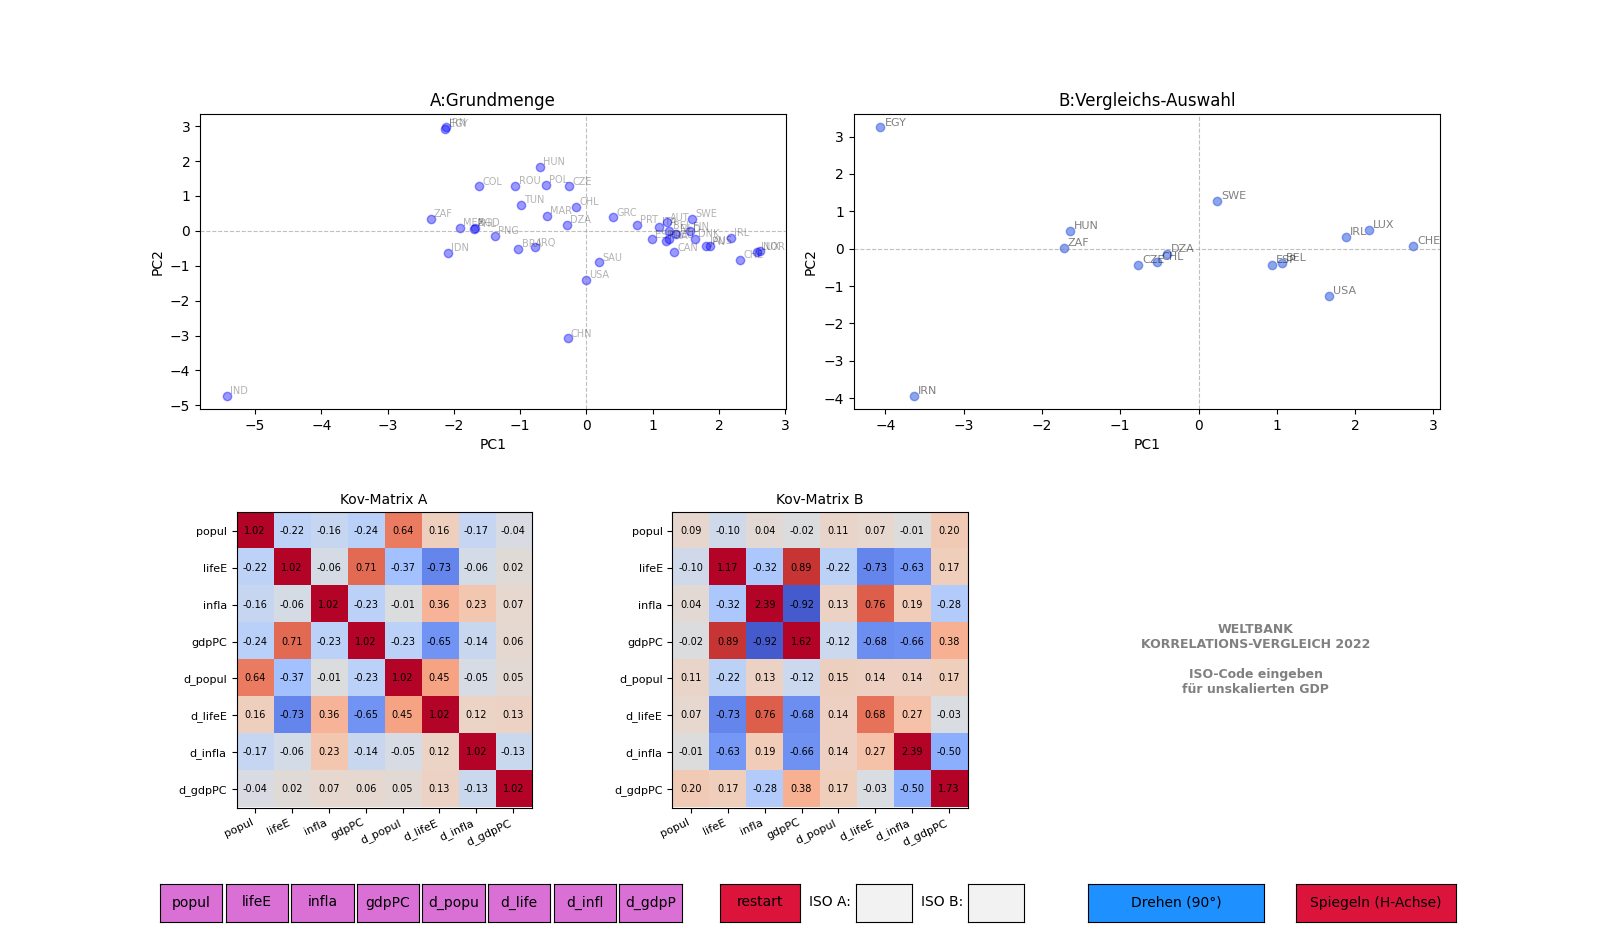

In [24]:
# AUFGABE 10 nach eigenem Ermessen 04_twin_plotter_2022.py
# =====================================================================
# MODUL 4 (TEIL 1 VON 3): MULTI-TYPE PLOTTER-KERN (ATTRIBUTE-FIX)
# =====================================================================
import matplotlib.pyplot as plt
from matplotlib.widgets import Button, TextBox
import numpy as np
import pandas as pd

monitor_title="WELTBANK\nKORRELATIONS-VERGLEICH 2022\n\nISO-Code eingeben\nfür unskalierten GDP"
file_A = "02_WB44-2022_A_Normalized.csv"
file_B = "03_WB44-2022_VerglAuswahl.csv"
file_C = "WBANK44_INDIK4.csv"

df_orig = pd.read_csv(file_A)
df_redu = pd.read_csv(file_B)

# Header-Namen von versteckten Leerzeichen befreien
df_orig.columns = df_orig.columns.str.strip()
df_redu.columns = df_redu.columns.str.strip()

# Alles außer Metadaten wird zum Feature
ALL_FEATURES = [
    c for c in df_orig.columns 
    if c.strip() not in ["ID_Number", "country", "iso3", "year"]
]
feature_states = {feat: True for feat in ALL_FEATURES}

rotation_state = 0
mirror_state = 1
idx_focus_A, idx_focus_B = None, None
filter_lock = False

PC1_orig, PC2_orig = None, None
PC1_base_redu, PC2_base_redu = None, None
cov_orig, cov_redu = None, None
evecs_redu, evals_redu = None, None
PC1_redu, PC2_redu = None, None
scatter_B = None

is_3d_mode = False
X3D_orig, Y3D_orig = None, None
X3D_redu_base, Y3D_redu_base = None, None
evecs_A_raw, evals_A_raw = None, None
evecs_B_raw, evals_B_raw = None, None

def project_dimetric_core(x_3d, y_3d, z_3d):
    """dimetrische Reiterperspektive"""
    alpha, beta = np.radians(7.0), np.radians(42.0)
    kx, ky, kz = 0.95, 1.0, 0.5
    x_2d = x_3d * kx * np.cos(alpha) - z_3d * kz * np.cos(beta)
    y_2d = y_3d * ky - x_3d * kx * np.sin(alpha) - z_3d * kz * np.sin(beta)
    return x_2d, y_2d

def project_dimetric(X_scaled):
    z = X_scaled[:, 2] if X_scaled.shape[1] > 2 else np.zeros(X_scaled.shape[0])
    return project_dimetric_core(X_scaled[:, 0], X_scaled[:, 1], z)

def recalculate_pca():
    global PC1_orig, PC2_orig, PC1_base_redu, PC2_base_redu, is_3d_mode
    global cov_orig, cov_redu, evecs_redu, evals_redu
    global X3D_orig, Y3D_orig, X3D_redu_base, Y3D_redu_base
    global evecs_A_raw, evals_A_raw, evecs_B_raw, evals_B_raw

    active_feats = [f for f in ALL_FEATURES if feature_states[f]]
    if len(active_feats) < 2: return False

    is_3d_mode = len(active_feats) == 3

    # CRASH-FIX: Erst erzwungene Text-Wandlung (.astype(str)), dann Whitespace-Kappung
    X_A = df_orig[active_feats].astype(str).stack().str.strip().astype(float).unstack().values
    cov_orig = np.cov(X_A, rowvar=False)
    evals_A, evecs_A = np.linalg.eigh(cov_orig)
    idx_A = np.argsort(evals_A)[::-1]
    evals_A_raw, evecs_A_raw = evals_A[idx_A], evecs_A[:, idx_A]

    X_B = df_redu[active_feats].astype(str).stack().str.strip().astype(float).unstack().values
    cov_redu = np.cov(X_B, rowvar=False)
    evals_B, evecs_B = np.linalg.eigh(cov_redu)
    idx_B = np.argsort(evals_B)[::-1]
    evals_redu, evecs_redu = evals_B[idx_B], evecs_B[:, idx_B]
    evals_B_raw, evecs_B_raw = evals_B[idx_B], evecs_B[:, idx_B]

    if is_3d_mode:
        X3D_orig, Y3D_orig = project_dimetric(X_A)
        X3D_redu_base, Y3D_redu_base = project_dimetric(X_B)
    else:
        PC1_orig = X_A @ evecs_A_raw[:, 0]
        PC2_orig = X_A @ evecs_A_raw[:, 1]
        PC1_base_redu = X_B @ evecs_redu[:, 0]
        PC2_base_redu = X_B @ evecs_redu[:, 1]
    return True

recalculate_pca()

# FIGUR-LAYOUT INITIALISIEREN
fig = plt.figure(figsize=(16, 9.5))
plt.rcParams["toolbar"] = "None"
ax_left = plt.subplot2grid((2, 6), (0, 0), colspan=3)
ax_right = plt.subplot2grid((2, 6), (0, 3), colspan=3)
ax_cov_A = plt.subplot2grid((2, 6), (1, 0), colspan=2)
ax_cov_B = plt.subplot2grid((2, 6), (1, 2), colspan=2)
ax_load = plt.subplot2grid((2, 6), (1, 4), colspan=2)
plt.subplots_adjust(bottom=0.15, hspace=0.35, wspace=0.45)
highlight_orig, highlight_redu = None, None
# =====================================================================
# MODUL 4 (TEIL 2 VON 3): RENDERING ENGINES & STRING-CLEANED RAW MONITOR
# =====================================================================

def draw_background_axes(ax, active_feats):
    """räumliches Koordinatensystem im Schrägbild"""
    if not is_3d_mode or len(active_feats) != 3:
        return
    axis_len = 2.0
    axes_3d = [
        (axis_len, 0, 0, active_feats, "darkred"),
        (0, axis_len, 0, active_feats, "darkgreen"),
        (0, 0, axis_len, active_feats, "darkblue"),
    ]
    for x3d, y3d, z3d, label, col in axes_3d:
        x2d, y2d = project_dimetric_core(x3d, y3d, z3d)
        ax.plot(
            [0, x2d],
            [0, y2d],
            color="darkgray",
            linestyle=":",
            linewidth=1.2,
            zorder=2,
        )
        ax.text(
            x2d * 1.1,
            y2d * 1.1,
            label,
            color=col,
            fontsize=8,
            weight="bold",
            ha="center",
            va="center",
            zorder=3,
        )


def draw_eigen_vectors(ax, evecs, evals, is_dataset_b=False):
    """Vektorpfeile als Skalare übergeben """
    if not is_3d_mode or evecs is None or len(evals) < 2:
        return
    len_pc1 = np.sqrt(evals) * 1.5
    len_pc2 = np.sqrt(evals) * 1.5

    v1_3d = evecs[:, 0] * len_pc1
    v2_3d = evecs[:, 1] * len_pc2

    if is_dataset_b:
        if rotation_state == 1:
            v1_3d, v2_3d = v2_3d, -v1_3d
        elif rotation_state == 2:
            v1_3d, v2_3d = -v1_3d, -v2_3d
        elif rotation_state == 3:
            v1_3d, v2_3d = -v2_3d, v1_3d
        v1_3d = v1_3d * mirror_state

    # ABSOLUTER SKALAR-ABGRIFF
    v1_2d_x, v1_2d_y = project_dimetric_core(v1_3d, v1_3d, v1_3d)
    v2_2d_x, v2_2d_y = project_dimetric_core(v2_3d, v2_3d, v2_3d)

    ax.arrow(
        0, 0, v1_2d_x, v1_2d_y, color="teal", width=0.03, head_width=0.12, zorder=10
    )
    ax.arrow(
        0,
        0,
        v2_2d_x,
        v2_2d_y,
        color="orange",
        width=0.03,
        head_width=0.12,
        zorder=10
    )


def draw_economic_monitor(ax):
    """Holt BIP aus der Ur-CSV und plottet ab"""
    ax.cla()
    active_idx = idx_focus_B if idx_focus_B is not None else idx_focus_A
    current_df = df_redu if idx_focus_B is not None else df_orig

    if active_idx is None or current_df.empty:
        ax.text(0.5,0.5,monitor_title,ha="center",va="center",color="gray",
                fontsize=9,weight="bold",)
        ax.set_axis_off()
        return
    try:
        # STRING-FIX: Extraktion des Textes aus der Zeilenserie
        raw_iso = current_df["iso3"].iloc[active_idx]
        if isinstance(raw_iso, pd.Series):
            raw_iso = raw_iso.iloc[0]
        target_iso = str(raw_iso).strip().upper()

        raw_country = current_df["country"].iloc[active_idx]
        if isinstance(raw_country, pd.Series):
            raw_country = raw_country.iloc[0]
        target_country = str(raw_country).strip()

        # Einlesen der originalen Weltbank-Basisdatei
        df_raw_wb = pd.read_csv(file_C, dtype=str)

        # Spalten-Sensor: Finde die Spalte für das Geld
        gdp_col = None
        for col in df_raw_wb.columns:
            if "GDP" in col.upper() or "PCAP" in col.upper():
                gdp_col = col
                break
        if gdp_col is None:
            gdp_col = "NY.GDP.PCAP.CD"

        # Ländercode-Vergleichsspalte im Speicher säubern
        df_raw_wb["iso3_clean"] = (
            df_raw_wb["iso3"].astype(str).str.strip().str.upper()
        )
        df_land = df_raw_wb[df_raw_wb["iso3_clean"] == target_iso].copy()

        if not df_land.empty:
            # Konvertierung über numerischen Schildwall
            df_land["year_num"] = pd.to_numeric(
                df_land["year"].astype(str).str.strip(), errors="coerce"
            )
            df_land["gdp_num"] = pd.to_numeric(
                df_land[gdp_col].astype(str).str.strip(), errors="coerce"
            )

            # Zeilen ohne gültige Werte eliminieren und chronologisch ordnen
            df_land = df_land.dropna(subset=["year_num", "gdp_num"]).sort_values(
                "year_num"
            )

            if not df_land.empty:
                ax.set_axis_on()
                # BIP Linienplot
                ax.plot(
                    df_land["year_num"].values,
                    df_land["gdp_num"].values,
                    color="crimson",
                    linewidth=2.0,
                )

                ax.set_title(
                    f"GDP-Trend: {target_country}",
                    fontsize=9,
                    weight="bold",
                    color="darkred",
                )
                ax.set_xlabel("Jahr", fontsize=7)
                ax.set_ylabel("GDP pro Kopf (in USD)", fontsize=7)

                # Währungs-Formatierung
                ax.get_yaxis().set_major_formatter(
                    plt.FuncFormatter(lambda x, loc: "{:,} $".format(int(x)))
                )
                ax.grid(True, linestyle="--", alpha=0.5)
                ax.tick_params(axis="both", labelsize=7)
                return
        raise ValueError
    except Exception:
        ax.text(
            0.5,
            0.5,
            f"Keine GDP-Urdaten für\n{target_iso} in der CSV gefunden.",
            ha="center",
            va="center",
            color="crimson",
            fontsize=9,
        )
        ax.set_axis_off()


def enforce_button_colors():
    for f in ALL_FEATURES:
        c = "orchid" if feature_states[f] else "lightgray"
        buttons_toggle[f].color = c
        buttons_toggle[f].hovercolor = c
        buttons_toggle[f].ax.set_facecolor(c)
# =====================================================================
# MODUL 4 (TEIL 3 VON 3): SCREEN REFRESH, WIDGETS & MAIN CALLBACKS
# =====================================================================

def update_plots(full_refresh=True):
    global PC1_redu, PC2_redu, highlight_orig, highlight_redu, scatter_B
    active_feats = [f for f in ALL_FEATURES if feature_states[f]]

    if is_3d_mode:
        if rotation_state == 0: p1, p2 = X3D_redu_base.copy(), Y3D_redu_base.copy()
        elif rotation_state == 1: p1, p2 = Y3D_redu_base.copy(), -X3D_redu_base.copy()
        elif rotation_state == 2: p1, p2 = -X3D_redu_base.copy(), -Y3D_redu_base.copy()
        elif rotation_state == 3: p1, p2 = -Y3D_redu_base.copy(), X3D_redu_base.copy()
        p1 = p1 * mirror_state; x_plot_A, y_plot_A = X3D_orig, Y3D_orig; x_plot_B, y_plot_B = p1, p2
    else:
        if rotation_state == 0: p1, p2 = PC1_base_redu.copy(), PC2_base_redu.copy()
        elif rotation_state == 1: p1, p2 = PC2_base_redu.copy(), -PC1_base_redu.copy()
        elif rotation_state == 2: p1, p2 = -PC1_base_redu.copy(), -PC2_base_redu.copy()
        elif rotation_state == 3: p1, p2 = -PC2_base_redu.copy(), PC1_base_redu.copy()
        p1 = p1 * mirror_state; x_plot_A, y_plot_A = PC1_orig, PC2_orig; x_plot_B, y_plot_B = p1, p2

    PC1_redu, PC2_redu = x_plot_B, y_plot_B

    if full_refresh:
        ax_left.cla(); ax_right.cla()
        for ax in [ax_left, ax_right]:
            ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
            ax.axvline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
            ax.set_xlabel("Perspektive X" if is_3d_mode else "PC1")
            ax.set_ylabel("Perspektive Y" if is_3d_mode else "PC2")

        if is_3d_mode and len(active_feats) == 3:
            draw_background_axes(ax_left, active_feats); draw_background_axes(ax_right, active_feats)

        ax_left.scatter(x_plot_A, y_plot_A, alpha=0.4, color="blue")
        (highlight_orig,) = ax_left.plot([], [], "ro", markersize=10, zorder=12)
        ax_left.set_title(f"A:Grundmenge")
        for i in range(len(x_plot_A)):
            ax_left.text(x_plot_A[i] + 0.05, y_plot_A[i] + 0.05, str(df_orig["iso3"].iloc[i]), fontsize=7, alpha=0.3)

        scatter_B = ax_right.scatter(x_plot_B, y_plot_B, alpha=0.6, color="royalblue")
        (highlight_redu,) = ax_right.plot([], [], "ro", markersize=10, zorder=12)
        ax_right.set_title(f"B:Vergleichs-Auswahl")
        for i in range(len(x_plot_B)):
            ax_right.text(x_plot_B[i] + 0.05, y_plot_B[i] + 0.05, str(df_redu["iso3"].iloc[i]), fontsize=8, alpha=0.5)

        if is_3d_mode:
            draw_eigen_vectors(ax_left, evecs_A_raw, evals_A_raw, is_dataset_b=False)
            draw_eigen_vectors(ax_right, evecs_B_raw, evals_B_raw, is_dataset_b=True)

        ax_cov_A.cla(); ax_cov_B.cla()
        for ax, cov, name in [(ax_cov_A, cov_orig, "A"), (ax_cov_B, cov_redu, "B")]:
            ax.imshow(cov, cmap="coolwarm", vmin=-1, vmax=1); ax.set_title(f"Kov-Matrix {name}", fontsize=10)
            ax.set_xticks(range(len(active_feats))); ax.set_yticks(range(len(active_feats)))
            ax.set_xticklabels(active_feats, rotation=25, ha="right", fontsize=8); ax.set_yticklabels(active_feats, fontsize=8)
            for i in range(len(active_feats)):
                for j in range(len(active_feats)): ax.text(j, i, f"{cov[i, j]:.2f}", ha="center", va="center", color="black", fontsize=7)
    else:
        if scatter_B is not None:
            scatter_B.set_offsets(np.column_stack((x_plot_B, y_plot_B)))
            if is_3d_mode:
                for p in list(ax_right.patches): p.remove()
                draw_background_axes(ax_right, active_feats)
                draw_eigen_vectors(ax_right, evecs_B_raw, evals_B_raw, is_dataset_b=True)

    if idx_focus_A is not None:
        highlight_orig.set_data([x_plot_A[idx_focus_A]], [y_plot_A[idx_focus_A]])
        ax_left.set_title(f"A: {df_orig['country'].iloc[idx_focus_A]}")
    if idx_focus_B is not None:
        highlight_redu.set_data([x_plot_B[idx_focus_B]], [y_plot_B[idx_focus_B]])
        ax_right.set_title(f"B: {df_redu['country'].iloc[idx_focus_B]}")

    draw_economic_monitor(ax_load)
    enforce_button_colors()
    fig.canvas.draw_idle()

def silence_hover(widget_button):
    widget_button.hovercolor = widget_button.color; widget_button._motion_notify = lambda event: None

# COCKPIT LAYOUT & WIDGET-INITIALISIERUNG
buttons_toggle = {}
x_start = 0.10
for idx, feat in enumerate(ALL_FEATURES):
    ax_btn = plt.axes([x_start + (idx * 0.041), 0.03, 0.039, 0.04])
    btn = Button(ax_btn, feat[:6], color="orchid"); silence_hover(btn); buttons_toggle[feat] = btn

def make_toggle_callback(f_name):
    def callback(event):
        global filter_lock
        if filter_lock: return
        if sum(feature_states.values()) <= 2 and feature_states[f_name]: return
        filter_lock = True; feature_states[f_name] = not feature_states[f_name]
        if recalculate_pca(): update_plots(full_refresh=True)
        filter_lock = False
    return callback

for feat in ALL_FEATURES: buttons_toggle[feat].on_clicked(make_toggle_callback(feat))

ax_btn_restart = plt.axes([0.45, 0.03, 0.05, 0.04])
btn_restart = Button(ax_btn_restart, "restart", color="crimson"); silence_hover(btn_restart)

def on_restart(event):
    global rotation_state, mirror_state, filter_lock, idx_focus_A, idx_focus_B
    if filter_lock: return
    filter_lock = True; rotation_state, mirror_state = 0, 1; idx_focus_A, idx_focus_B = None, None
    for f in ALL_FEATURES: feature_states[f] = True
    recalculate_pca(); update_plots(full_refresh=True); filter_lock = False
btn_restart.on_clicked(on_restart)

ax_box_l = plt.axes([0.535, 0.03, 0.035, 0.04]); text_box_l = TextBox(ax_box_l, "ISO A: ", initial="")
ax_box_r = plt.axes([0.605,0.03, 0.035, 0.04]); text_box_r = TextBox(ax_box_r, "ISO B: ", initial="")

def submit_left(text):
    global idx_focus_A
    try:
        val = str(text).strip().upper(); match = df_orig[df_orig["iso3"] == val]
        idx_focus_A = df_orig.index[df_orig["iso3"] == val].tolist() if not match.empty else None
        update_plots(full_refresh=True)
    except Exception: idx_focus_A = None

def submit_right(text):
    global idx_focus_B
    try:
        val = str(text).strip().upper(); match = df_redu[df_redu["iso3"] == val]
        idx_focus_B = df_redu.index[df_redu["iso3"] == val].tolist() if not match.empty else None
        update_plots(full_refresh=True)
    except Exception: idx_focus_B = None

text_box_l.on_submit(submit_left); text_box_r.on_submit(submit_right)

ax_btn_rot = plt.axes([0.68, 0.03, 0.11, 0.04]); btn_rotate = Button(ax_btn_rot, "Drehen (90°)", color="dodgerblue"); silence_hover(btn_rotate)
ax_btn_mir = plt.axes([0.81, 0.03, 0.10, 0.04]); btn_mirror = Button(ax_btn_mir, "Spiegeln (H-Achse)", color="crimson"); silence_hover(btn_mirror)

def rotate_reduktion(event): global rotation_state; rotation_state = (rotation_state + 1) % 4; update_plots(full_refresh=False)
def mirror_reduktion(event): global mirror_state; mirror_state = -1 if mirror_state == 1 else 1; update_plots(full_refresh=False)
btn_rotate.on_clicked(rotate_reduktion); btn_mirror.on_clicked(mirror_reduktion)

# Das initiale Update 
update_plots(full_refresh=True)
plt.show()
        




**Exercise 5**
Generate two samples of size 50: one from an exponential distribution with rate 1, the other from a normal distribution with mean 1 and standard deviation 1. Use a Kolmogorov-Smirnov test (`stats.kstest`) to test whether each sample could come from a normal distribution. Interpret the p-values. Then use a chi-squared test on binned data to test the same hypothesis.

In [ ]:
# Exercise 5

**Exercise 6**
A **QQ-plot** (quantile-quantile plot) compares the quantiles of a sample against the theoretical quantiles of a reference distribution. If the data follow the reference distribution, the points lie on a straight line. Use `stats.probplot(data, dist="norm", plot=plt)` to create QQ-plots for: (a) 200 samples from a standard normal, (b) 200 samples from an exponential distribution, (c) 200 samples from a $t$-distribution with 3 degrees of freedom (`stats.t.rvs(df=3, size=200)`). Which sample deviates most from normality, and how does the deviation appear in the QQ-plot?

In [ ]:
# Exercise 6

**Exercise 7**
Generate two samples: `sample_a` from $\mathcal{N}(5, 1)$ (size 30) and `sample_b` from $\mathcal{N}(5.5, 1)$ (size 30). Perform a two-sample t-test. Then repeat this experiment 1000 times and count how often the test rejects at level $\alpha = 0.05$. This is the empirical power of the test. How does it change if you increase the sample size to 100?

In [ ]:
# Exercise 6

**Exercise 8**
Using the [World Bank API](https://datahelpdesk.worldbank.org/knowledgebase/articles/889392-about-the-indicators-api-documentation) (see @sec-loading-online), fetch GDP per capita (`NY.GDP.PCAP.CD`) and life expectancy (`SP.DYN.LE00.IN`) for all countries for the year 2022. Drop missing values. Use `stats.pearsonr` and `stats.spearmanr` to compute both correlation coefficients. Create a scatter plot of GDP per capita vs. life expectancy. Why does the Spearman correlation differ from the Pearson correlation? Hint: try plotting GDP on a log scale (`plt.xscale("log")`).

In [ ]:
# Exercise 8

**Exercise 9**
Using the World Bank API, fetch Germany's total population (`SP.POP.TOTL`) for each year from 1960 to 2023. Use `stats.linregress` to fit a linear trend to the data. Plot the population over time together with the regression line. Compute the residuals and plot them. Does a linear model fit well? What happens around 1990?

In [ ]:
# Exercise 9

**Exercise 10**
Using the World Bank API, fetch GDP per capita (`NY.GDP.PCAP.CD`) for all countries for the years 2010 and 2020. Merge the two years into a single DataFrame so that each country has columns `gdp_2010` and `gdp_2020`. Drop rows with missing values. Use a paired t-test (`stats.ttest_rel`) to test whether GDP per capita has changed significantly. Then fit a normal distribution to the differences `gdp_2020 - gdp_2010` using `stats.norm.fit` and plot the histogram together with the fitted density.

In [ ]:
# Exercise 10

**Exercise 11**
Generate 200 samples from a mixture of two normals: with probability 0.4 draw from $\mathcal{N}(-2, 1)$, otherwise from $\mathcal{N}(3, 0.5^2)$. Write a function that computes the negative log-likelihood of a two-component Gaussian mixture (with 5 parameters: $\mu_1, \sigma_1, \mu_2, \sigma_2, p$). Use `scipy.optimize.minimize` to find the MLE. Plot the histogram and the fitted density.

In [ ]:
# Exercise 11

**Exercise 12**
Using the World Bank API, fetch life expectancy (`SP.DYN.LE00.IN`) and GDP per capita (`NY.GDP.PCAP.CD`) for all countries for the year 2022. Drop missing values. Standardize both variables. Perform PCA on the two-dimensional data. What fraction of the variance is explained by the first principal component? Plot the data in the original and in the PCA coordinate system. Does PCA help here, given that there are only two features?

In [ ]:
# Exercise 12